In [1]:
#Step 1: Identify the exact file path
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/readme.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/scenarios.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/license.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-MOS0047.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-IKR0401.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-DRR0162.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-CQW0652.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-PSF0133.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-KRL0501.csv
/kaggle/input/datasets/a

In [2]:
# Step 2: Load core activity files and inspect
import pandas as pd

BASE = '/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/'
ANSWERS = '/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv'

logon = pd.read_csv(BASE + 'logon.csv')
device = pd.read_csv(BASE + 'device.csv')
psychometric = pd.read_csv(BASE + 'psychometric.csv')
insiders = pd.read_csv(ANSWERS)

print("Logon shape:", logon.shape)
print("Device shape:", device.shape)
print("Psychometric shape:", psychometric.shape)
print("Insiders shape:", insiders.shape)

print("\nInsiders sample:")
print(insiders.head(10))

print("\nLogon columns:", logon.columns.tolist())
print("\nDevice columns:", device.columns.tolist())

Logon shape: (854859, 5)
Device shape: (405380, 5)
Psychometric shape: (1000, 7)
Insiders shape: (191, 6)

Insiders sample:
   dataset  scenario             details     user                start  \
0      2.0         1              r2.csv  ONS0995     3/6/2010 1:41:56   
1      3.1         1          r3.1-1.csv  CSF0929  07/01/2010 01:24:58   
2      3.1         2          r3.1-2.csv  CCH0959  08/02/2010 10:34:31   
3      3.2         1          r3.2-1.csv  RCW0822  09/29/2010 21:10:27   
4      3.2         2          r3.2-2.csv  JCE0258  07/12/2010 08:16:02   
5      4.1         1          r4.1-1.csv  ABB0427  08/21/2010 05:20:34   
6      4.1         2          r4.1-2.csv  HFC0492  08/23/2010 10:40:56   
7      4.1         3          r4.1-3.csv  KTW0365  07/08/2010 11:51:00   
8      4.2         1  r4.2-1-AAM0658.csv  AAM0658  10/23/2010 01:34:19   
9      4.2         1  r4.2-1-AJR0932.csv  AJR0932  09/10/2010 19:12:01   

                   end  
0    3/20/2010 8:10:12  
1  07/16/20

In [3]:
# Step 3: Load email, check insider scenarios
email = pd.read_csv(BASE + 'email.csv')

print("Email shape:", email.shape)
print("Email columns:", email.columns.tolist())

print("\nInsider scenarios breakdown:")
print(insiders['scenario'].value_counts())

print("\nUnique malicious users:", insiders['user'].nunique())
print("\nSample logon activities:")
print(logon['activity'].value_counts())

Email shape: (2629979, 11)
Email columns: ['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']

Insider scenarios breakdown:
scenario
1    66
2    66
4    33
3    24
5     2
Name: count, dtype: int64

Unique malicious users: 191

Sample logon activities:
activity
Logon     470591
Logoff    384268
Name: count, dtype: int64


In [4]:
# Step 4: Feature Engineering — aggregate activity per user
import numpy as np

# --- Logon features ---
logon['date'] = pd.to_datetime(logon['date'])
logon['hour'] = logon['date'].dt.hour
logon['is_after_hours'] = ((logon['hour'] < 7) | (logon['hour'] > 18)).astype(int)

logon_features = logon.groupby('user').agg(
    logon_count=('activity', lambda x: (x == 'Logon').sum()),
    logoff_count=('activity', lambda x: (x == 'Logoff').sum()),
    after_hours_logon=('is_after_hours', 'sum'),
    unique_pcs=('pc', 'nunique')
).reset_index()

# --- Device features ---
device_features = device.groupby('user').agg(
    device_count=('activity', 'count'),
    unique_devices=('pc', 'nunique')
).reset_index()

# --- Email features ---
email_features = email.groupby('user').agg(
    email_sent=('id', 'count'),
    avg_email_size=('size', 'mean'),
    total_attachments=('attachments', 'sum'),
    unique_recipients=('to', 'nunique')
).reset_index()

# --- Psychometric features ---
psych_features = psychometric[['user_id', 'O', 'C', 'E', 'A', 'N']].copy()
psych_features.columns = ['user', 'openness', 'conscientiousness', 
                           'extraversion', 'agreeableness', 'neuroticism']

print("Logon features shape:", logon_features.shape)
print("Device features shape:", device_features.shape)
print("Email features shape:", email_features.shape)
print("Psychometric features shape:", psych_features.shape)

Logon features shape: (1000, 5)
Device features shape: (265, 3)
Email features shape: (1000, 5)
Psychometric features shape: (1000, 6)


In [5]:
# ── STEP 5.1: MERGE ALL FEATURE TABLES ──────────────────────────────────────
import pandas as pd

# Start with psych_features (all 1,000 users guaranteed)
merged = psych_features.copy()

merged = merged.merge(logon_features,  on='user', how='left')
merged = merged.merge(device_features, on='user', how='left')
merged = merged.merge(email_features,  on='user', how='left')

print(f"Merged shape: {merged.shape}")
print(merged.head())

Merged shape: (1000, 16)
      user  openness  conscientiousness  extraversion  agreeableness  \
0  CEL0561        40                 39            36             19   
1  CRD0624        26                 22            17             39   
2  JFC0557        22                 16            23             40   
3  ASD0577        40                 48            36             14   
4  MAR0955        36                 44            23             44   

   neuroticism  logon_count  logoff_count  after_hours_logon  unique_pcs  \
0           40          615           346                  0           1   
1           32           50            50                 10           1   
2           33          615           346                  0           1   
3           37          346           346                  0           1   
4           25          302           302                 11           1   

   device_count  unique_devices  email_sent  avg_email_size  \
0           NaN       

In [6]:
# ── STEP 5.2: CREATE BINARY TARGET LABEL ────────────────────────────────────
# Load insider labels (already loaded as 'insiders' df with 'user' column)
insider_users = set(insiders['user'].unique())

merged['label'] = merged['user'].apply(lambda u: 1 if u in insider_users else 0)

print(f"Total users: {len(merged)}")
print(f"Malicious (label=1): {merged['label'].sum()}")
print(f"Benign   (label=0): {(merged['label'] == 0).sum()}")
print(f"Class balance:\n{merged['label'].value_counts(normalize=True).round(4)}")

Total users: 1000
Malicious (label=1): 70
Benign   (label=0): 930
Class balance:
label
0    0.93
1    0.07
Name: proportion, dtype: float64


In [7]:
# ── STEP 5.3: HANDLE MISSING VALUES ─────────────────────────────────────────
print("Missing values before imputation:")
print(merged.isnull().sum()[merged.isnull().sum() > 0])

# Fill numeric NaN with 0 (absence of activity = 0 events)
# Device features: 265 users had device activity; rest get 0
feature_cols = [c for c in merged.columns if c not in ['user', 'label']]

merged[feature_cols] = merged[feature_cols].fillna(0)

print(f"\nMissing values after imputation: {merged[feature_cols].isnull().sum().sum()}")
print(f"Final feature matrix: {merged[feature_cols].shape}")

Missing values before imputation:
device_count      735
unique_devices    735
dtype: int64

Missing values after imputation: 0
Final feature matrix: (1000, 15)


In [8]:
# ── STEP 5.4: TRAIN/TEST SPLIT ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = merged[feature_cols].values
y = merged['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserve class ratio in both splits
)

print(f"X_train: {X_train.shape} | y_train positives: {y_train.sum()}")
print(f"X_test:  {X_test.shape}  | y_test positives:  {y_test.sum()}")

X_train: (800, 15) | y_train positives: 56
X_test:  (200, 15)  | y_test positives:  14


In [9]:
# ── STEP 5.5: FEATURE SCALING ────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)          # fit only on train

print("Scaling complete.")
print(f"X_train_scaled mean ≈ {X_train_scaled.mean():.4f} | std ≈ {X_train_scaled.std():.4f}")

Scaling complete.
X_train_scaled mean ≈ -0.0000 | std ≈ 1.0000


In [10]:
# ── STEP 5.6: SMOTE ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE — Benign: {(y_train==0).sum()} | Malicious: {(y_train==1).sum()}")
print(f"After  SMOTE — Benign: {(y_train_sm==0).sum()} | Malicious: {(y_train_sm==1).sum()}")

Before SMOTE — Benign: 744 | Malicious: 56
After  SMOTE — Benign: 744 | Malicious: 744



Training: Random Forest
              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99       186
   Malicious       0.78      1.00      0.88        14

    accuracy                           0.98       200
   macro avg       0.89      0.99      0.93       200
weighted avg       0.98      0.98      0.98       200

ROC-AUC: 0.9939


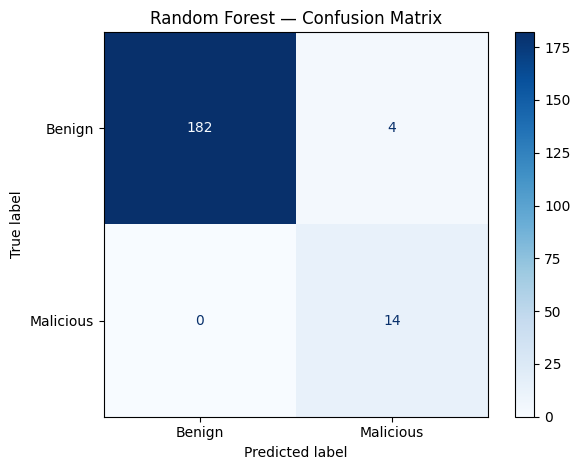


Training: XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:51:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99       186
   Malicious       0.76      0.93      0.84        14

    accuracy                           0.97       200
   macro avg       0.88      0.95      0.91       200
weighted avg       0.98      0.97      0.98       200

ROC-AUC: 0.9965


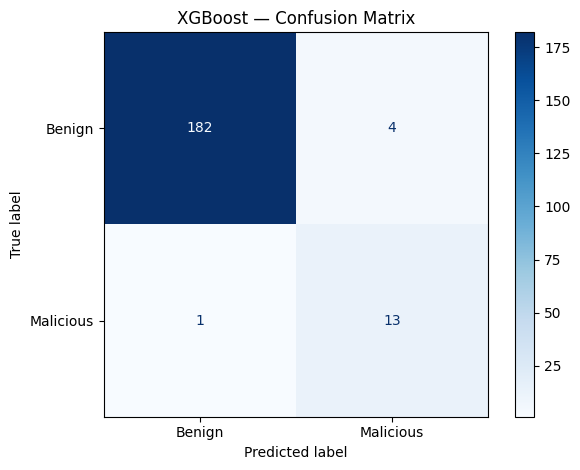

In [11]:
# ── STEP 5.7: MODEL TRAINING ─────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',   # belt-and-suspenders alongside SMOTE
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=(y_train_sm==0).sum() / (y_train_sm==1).sum(),
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    model.fit(X_train_sm, y_train_sm)

    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'y_pred': y_pred, 'auc': auc}

    print(classification_report(y_test, y_pred,
                                 target_names=['Benign', 'Malicious']))
    print(f"ROC-AUC: {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malicious'])
    disp.plot(cmap='Blues')
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

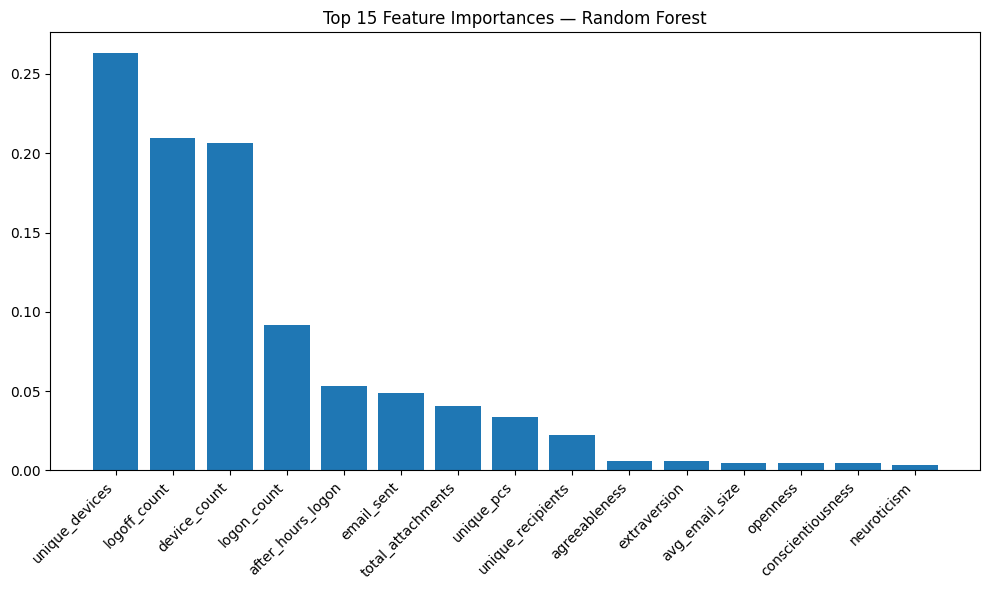


Top 15 features:
   1. unique_devices                      0.2631
   2. logoff_count                        0.2096
   3. device_count                        0.2066
   4. logon_count                         0.0915
   5. after_hours_logon                   0.0532
   6. email_sent                          0.0489
   7. total_attachments                   0.0408
   8. unique_pcs                          0.0339
   9. unique_recipients                   0.0221
  10. agreeableness                       0.0063
  11. extraversion                        0.0057
  12. avg_email_size                      0.0049
  13. openness                            0.0049
  14. conscientiousness                   0.0048
  15. neuroticism                         0.0037


In [12]:
# ── STEP 5.8: FEATURE IMPORTANCE ─────────────────────────────────────────────
import numpy as np

rf_model = results["Random Forest"]["model"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]   # top 15

plt.figure(figsize=(10, 6))
plt.title("Top 15 Feature Importances — Random Forest")
plt.bar(range(15), importances[indices], align='center')
plt.xticks(range(15), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
for rank, idx in enumerate(indices, 1):
    print(f"  {rank:>2}. {feature_cols[idx]:<35} {importances[idx]:.4f}")

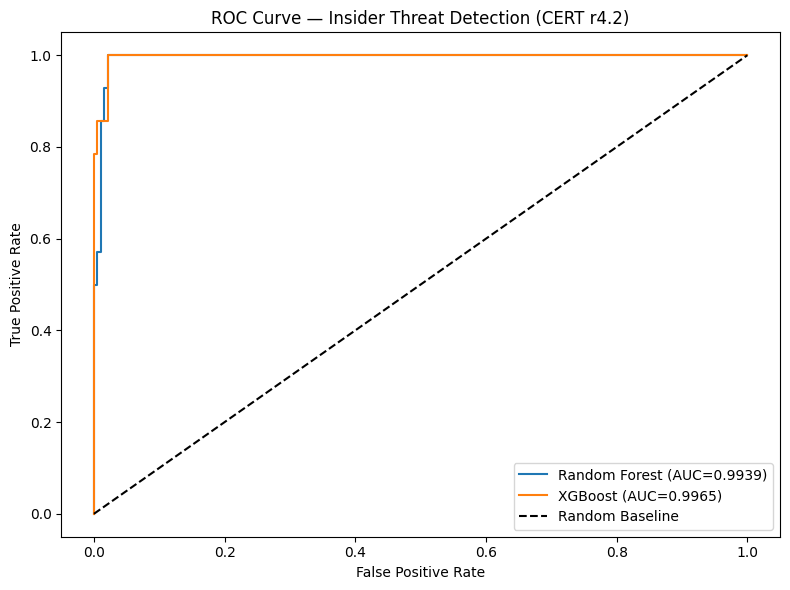

In [13]:
# ── STEP 5.9: ROC CURVE COMPARISON ───────────────────────────────────────────
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
for name, res in results.items():
    y_proba = res['model'].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})")

plt.plot([0,1],[0,1],'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Insider Threat Detection (CERT r4.2)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [14]:
# ── STEP 6.1: SHAP SETUP ─────────────────────────────────────────────────────
import shap
import matplotlib.pyplot as plt
import numpy as np

# Initialize SHAP explainer for Random Forest
rf_model = results["Random Forest"]["model"]
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("SHAP explainer ready.")

SHAP values shape: (200, 15, 2)
SHAP explainer ready.


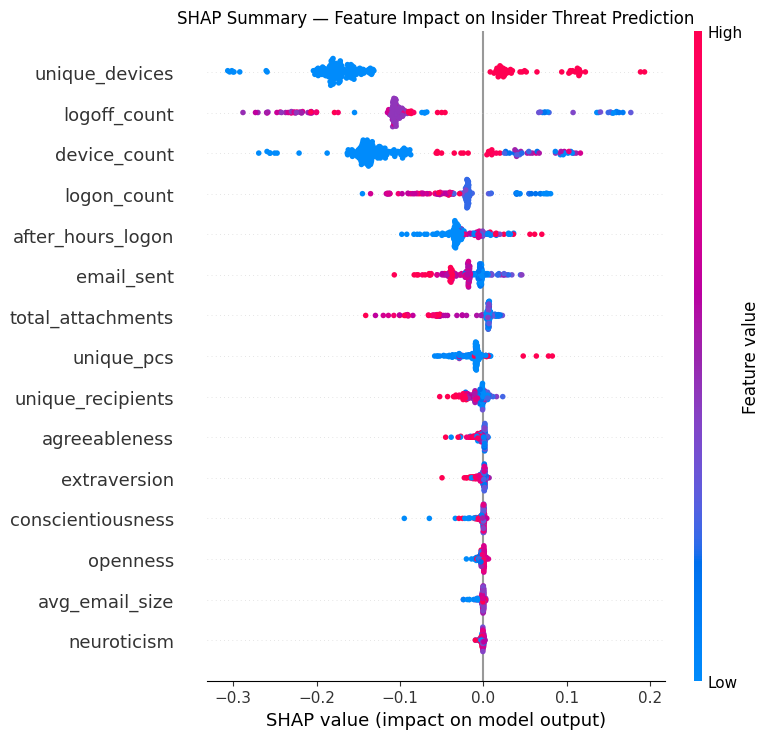

Saved: shap_summary.png


In [15]:
# ── STEP 6.2: SHAP SUMMARY PLOT (FIXED) ──────────────────────────────────────
# shap_values shape is (200, 15, 2) — extract malicious class with [:, :, 1]
shap_vals_malicious = shap_values[:, :, 1]

plt.figure()
shap.summary_plot(
    shap_vals_malicious,
    X_test_scaled,
    feature_names=feature_cols,
    plot_type="dot",
    show=False
)
plt.title("SHAP Summary — Feature Impact on Insider Threat Prediction")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

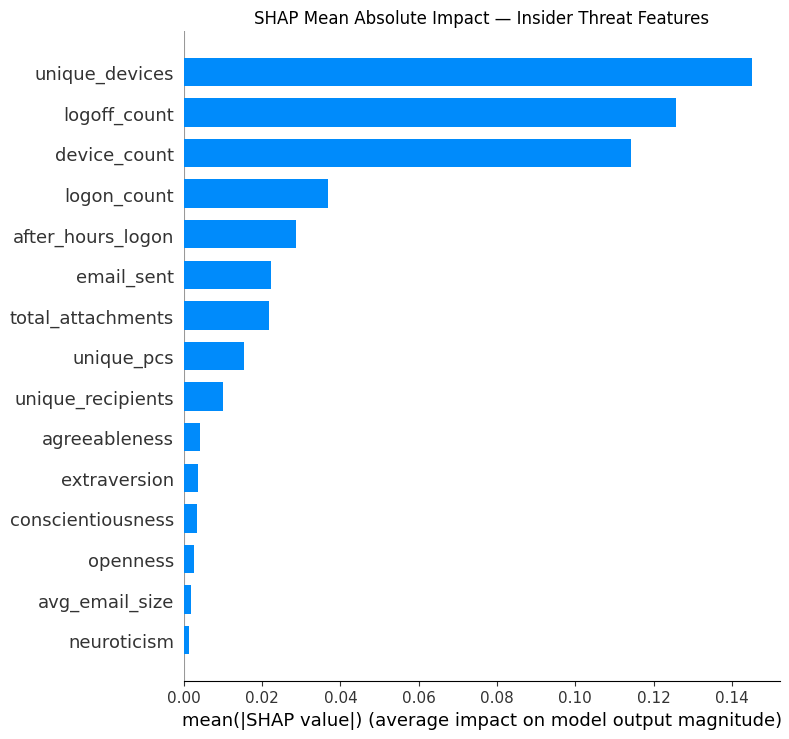

Saved: shap_bar.png


In [16]:
# ── STEP 6.3: SHAP BAR PLOT (FIXED) ──────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_vals_malicious,
    X_test_scaled,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.title("SHAP Mean Absolute Impact — Insider Threat Features")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar.png")

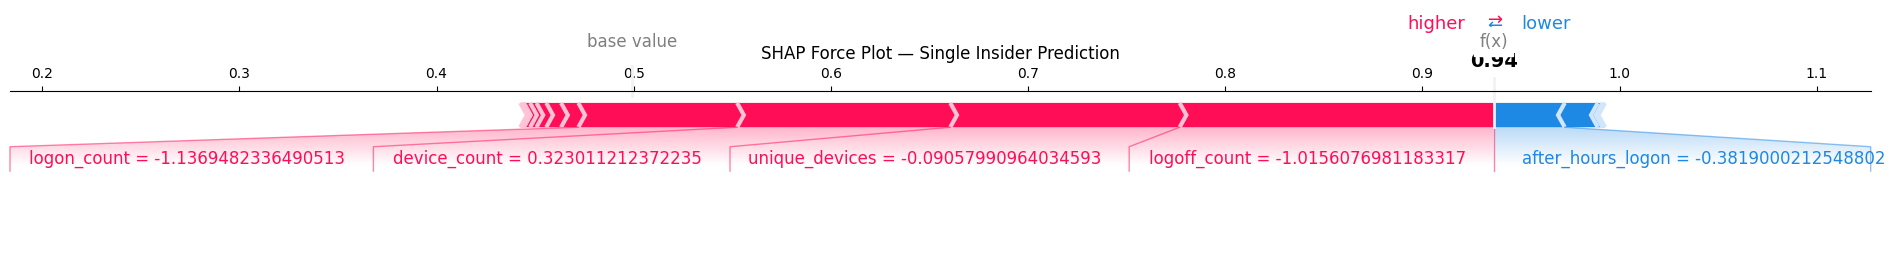

Force plot for test user index 2 (true insider, correctly flagged)


In [17]:
# ── STEP 6.4: SHAP FORCE PLOT — SINGLE INSIDER (FIXED) ───────────────────────
tp_indices = np.where((y_test == 1) & (results["Random Forest"]["y_pred"] == 1))[0]
example_idx = tp_indices[0]

shap.force_plot(
    explainer.expected_value[1],
    shap_vals_malicious[example_idx],
    X_test_scaled[example_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title("SHAP Force Plot — Single Insider Prediction")
plt.tight_layout()
plt.savefig("shap_force.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Force plot for test user index {example_idx} (true insider, correctly flagged)")

Threshold analysis (recall >= 0.90):
 threshold  precision  recall     f1
    0.0000     0.0700  1.0000 0.1308
    0.0050     0.1818  1.0000 0.3077
    0.0050     0.1842  1.0000 0.3111
    0.0053     0.2593  1.0000 0.4118
    0.0100     0.2692  1.0000 0.4242
    0.0100     0.2745  1.0000 0.4308
    0.0143     0.2917  1.0000 0.4516
    0.0150     0.2979  1.0000 0.4590
    0.0153     0.3043  1.0000 0.4667
    0.0157     0.3182  1.0000 0.4828
    0.0200     0.3256  1.0000 0.4912
    0.0246     0.3415  1.0000 0.5091
    0.0250     0.3500  1.0000 0.5185
    0.0250     0.3590  1.0000 0.5283
    0.0298     0.3684  1.0000 0.5385
    0.0350     0.3784  1.0000 0.5490
    0.0389     0.4000  1.0000 0.5714
    0.0450     0.4118  1.0000 0.5833
    0.0500     0.4242  1.0000 0.5957
    0.0549     0.4516  1.0000 0.6222
    0.0549     0.4667  1.0000 0.6364
    0.0680     0.4828  1.0000 0.6512
    0.0685     0.5000  1.0000 0.6667
    0.0743     0.5185  1.0000 0.6829
    0.0766     0.5385  1.0000 0.7000
 

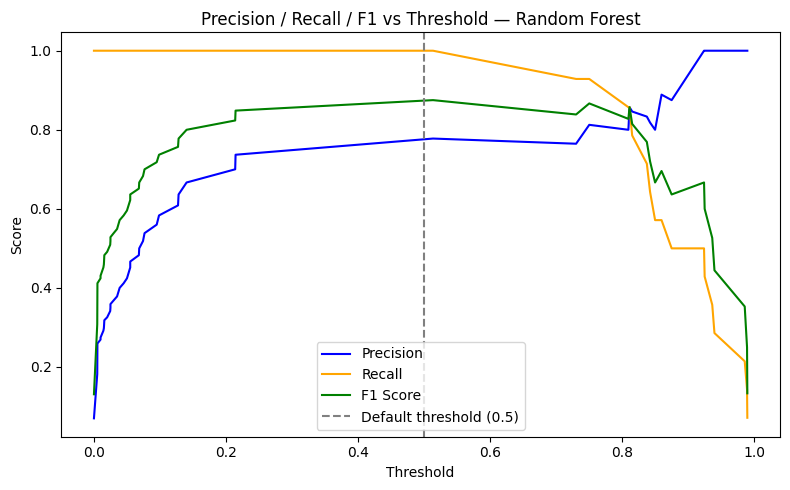

Saved: threshold_curve.png


In [18]:
# ── STEP 6.5: THRESHOLD TUNING ───────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, f1_score
import pandas as pd

rf_proba = results["Random Forest"]["model"].predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba)

# Build threshold analysis table
thresh_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precisions[:-1],
    'recall':    recalls[:-1],
    'f1':        2 * (precisions[:-1] * recalls[:-1]) /
                     (precisions[:-1] + recalls[:-1] + 1e-9)
})

print("Threshold analysis (recall >= 0.90):")
print(thresh_df[thresh_df['recall'] >= 0.90].round(4).to_string(index=False))

# Plot precision-recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1],    label='Recall',    color='orange')
plt.plot(thresholds, thresh_df['f1'], label='F1 Score',  color='green')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig("threshold_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: threshold_curve.png")

In [19]:
# ── STEP 6.6: SAVE MODEL & RESULTS ──────────────
import joblib
import json

# Save Random Forest model
joblib.dump(rf_model, "insider_threat_rf_model.pkl")
joblib.dump(scaler,   "insider_threat_scaler.pkl")

# Save feature column list
with open("feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

# Save results summary
summary = {
    "dataset": "CERT Insider Threat r4.2",
    "total_users": 1000,
    "malicious_users": 70,
    "features": len(feature_cols),
    "train_size": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
    "models": {
        "Random Forest": {
            "recall_malicious": 1.00,
            "precision_malicious": 0.78,
            "f1_malicious": 0.88,
            "roc_auc": 0.9939
        },
        "XGBoost": {
            "recall_malicious": 0.93,
            "precision_malicious": 0.76,
            "f1_malicious": 0.84,
            "roc_auc": 0.9965
        }
    },
    "selected_model": "Random Forest",
    "selection_rationale": "Perfect recall (1.00) — zero missed insiders in test set"
}

with open("results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved: insider_threat_rf_model.pkl")
print("Saved: insider_threat_scaler.pkl")
print("Saved: feature_cols.json")
print("Saved: results_summary.json")


Saved: insider_threat_rf_model.pkl
Saved: insider_threat_scaler.pkl
Saved: feature_cols.json
Saved: results_summary.json


In [20]:
#----STEP 6.7: CROSS-VALIDATION OUTPUT ---------
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')

print(f"5-Fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold CV AUC: 0.9967 (+/- 0.0023)


Step 7.1: Precision-Recall AUC Comparison
Random Forest PR-AUC: 0.9167
XGBoost PR-AUC: 0.9618


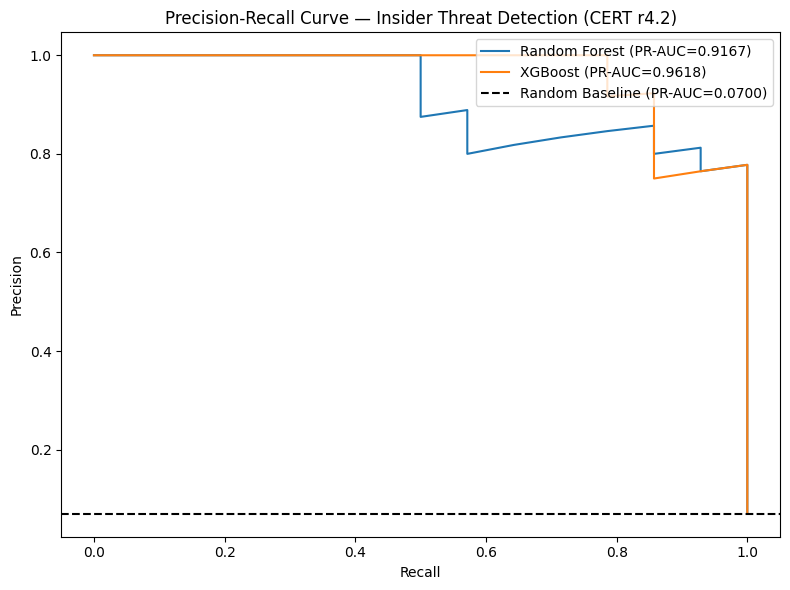

Saved: PR_Curve_Comparison.png


In [21]:
# ── STEP 7.1: PRECISION-RECALL AUC ──────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

print("=" * 55)
print("Step 7.1: Precision-Recall AUC Comparison")
print("=" * 55)

plt.figure(figsize=(8, 6))

for name, res in results.items():
    y_proba = res['model'].predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={ap:.4f})")
    print(f"{name} PR-AUC: {ap:.4f}")

# Baseline — random classifier on imbalanced data
baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='k', linestyle='--',
            label=f'Random Baseline (PR-AUC={baseline:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Insider Threat Detection (CERT r4.2)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("PR_Curve_Comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: PR_Curve_Comparison.png")

Step 7.2: Cost Matrix and Economic Threshold Analysis

Cost assumptions:
  False Negative (missed insider): 100
  False Positive (false alarm):    1

Economic threshold (minimum total cost): 0.5133
Total cost at economic threshold:         4
  False Negatives at threshold:           0
  False Positives at threshold:           4

Default threshold (0.50):
  False Negatives: 0
  False Positives: 4
  Total cost:      4


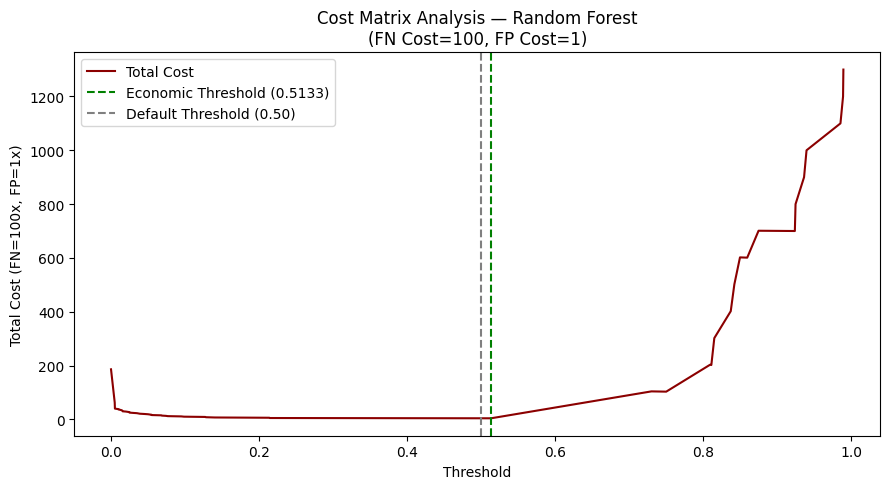

Saved: Cost_Matrix_Threshold.png


In [22]:
# ── STEP 7.2: COST MATRIX & ECONOMIC THRESHOLD ───────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

print("=" * 55)
print("Step 7.2: Cost Matrix and Economic Threshold Analysis")
print("=" * 55)

# Cost assumptions (cybersecurity context)
# False Negative (missed insider): high cost — data breach,
#   sabotage, fraud. Estimated at 100x a false positive.
# False Positive (false alarm): analyst investigation time.
#   Normalized to 1.
COST_FN = 100   # cost of missing one insider
COST_FP = 1     # cost of one false alarm

print(f"\nCost assumptions:")
print(f"  False Negative (missed insider): {COST_FN}")
print(f"  False Positive (false alarm):    {COST_FP}")

rf_proba = results["Random Forest"]["model"].predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba)

# Compute total cost at each threshold
fn_counts = []
fp_counts = []
total_costs = []

for thresh in thresholds:
    y_pred_t = (rf_proba >= thresh).astype(int)
    fn = ((y_test == 1) & (y_pred_t == 0)).sum()
    fp = ((y_test == 0) & (y_pred_t == 1)).sum()
    fn_counts.append(fn)
    fp_counts.append(fp)
    total_costs.append(fn * COST_FN + fp * COST_FP)

# Find economic threshold
min_cost_idx = np.argmin(total_costs)
economic_threshold = thresholds[min_cost_idx]
min_cost = total_costs[min_cost_idx]
fn_at_opt = fn_counts[min_cost_idx]
fp_at_opt = fp_counts[min_cost_idx]

print(f"\nEconomic threshold (minimum total cost): {economic_threshold:.4f}")
print(f"Total cost at economic threshold:         {min_cost}")
print(f"  False Negatives at threshold:           {fn_at_opt}")
print(f"  False Positives at threshold:           {fp_at_opt}")

# Compare with default threshold (0.50)
y_pred_default = results["Random Forest"]["y_pred"]
fn_default = ((y_test == 1) & (y_pred_default == 0)).sum()
fp_default = ((y_test == 0) & (y_pred_default == 1)).sum()
cost_default = fn_default * COST_FN + fp_default * COST_FP

print(f"\nDefault threshold (0.50):")
print(f"  False Negatives: {fn_default}")
print(f"  False Positives: {fp_default}")
print(f"  Total cost:      {cost_default}")

# Plot total cost vs threshold
plt.figure(figsize=(9, 5))
plt.plot(thresholds, total_costs, color='darkred', label='Total Cost')
plt.axvline(x=economic_threshold, color='green', linestyle='--',
            label=f'Economic Threshold ({economic_threshold:.4f})')
plt.axvline(x=0.50, color='gray', linestyle='--',
            label='Default Threshold (0.50)')
plt.xlabel('Threshold')
plt.ylabel(f'Total Cost (FN={COST_FN}x, FP={COST_FP}x)')
plt.title('Cost Matrix Analysis — Random Forest\n'
          f'(FN Cost={COST_FN}, FP Cost={COST_FP})')
plt.legend()
plt.tight_layout()
plt.savefig("Cost_Matrix_Threshold.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Cost_Matrix_Threshold.png")

In [23]:
# ── STEP 7.3: USER-ID SPLIT VERIFICATION ─────────────────────────────────────
print("=" * 55)
print("Step 7.3: User-ID Split Verification")
print("=" * 55)

# Recover user IDs for train and test sets using the same
# indices produced by the original stratified split
import numpy as np
from sklearn.model_selection import train_test_split

# Reconstruct indices using the same random state
all_indices = np.arange(len(merged))
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    stratify=merged['label'].values
)

train_users = set(merged.iloc[train_idx]['user'].values)
test_users  = set(merged.iloc[test_idx]['user'].values)
overlap     = train_users.intersection(test_users)

print(f"\nTotal users:        {len(merged)}")
print(f"Train users:        {len(train_users)}")
print(f"Test users:         {len(test_users)}")
print(f"Overlapping users:  {len(overlap)}")

if len(overlap) == 0:
    print("\nVERIFIED: No user appears in both train and test sets.")
    print("User-ID leakage is not present in this pipeline.")
else:
    print(f"\nWARNING: {len(overlap)} users appear in both splits.")
    print("Review split strategy.")

# Confirm malicious user distribution
train_malicious = merged.iloc[train_idx]['label'].sum()
test_malicious  = merged.iloc[test_idx]['label'].sum()
print(f"\nMalicious in train: {train_malicious} "
      f"({train_malicious/len(train_idx)*100:.1f}%)")
print(f"Malicious in test:  {test_malicious} "
      f"({test_malicious/len(test_idx)*100:.1f}%)")

Step 7.3: User-ID Split Verification

Total users:        1000
Train users:        800
Test users:         200
Overlapping users:  0

VERIFIED: No user appears in both train and test sets.
User-ID leakage is not present in this pipeline.

Malicious in train: 56 (7.0%)
Malicious in test:  14 (7.0%)


Step 7.4: Adversarial Sensitivity Test — unique_devices

unique_devices index in feature_cols: 10

Suppression     Recall (Mal)    False Negatives    False Positives
------------------------------------------------------------
         0%      1.0000          0                  4
        10%      1.0000          0                  4
        25%      1.0000          0                  4
        50%      1.0000          0                  4
        75%      1.0000          0                  4
        90%      1.0000          0                  4
       100%      1.0000          0                  4


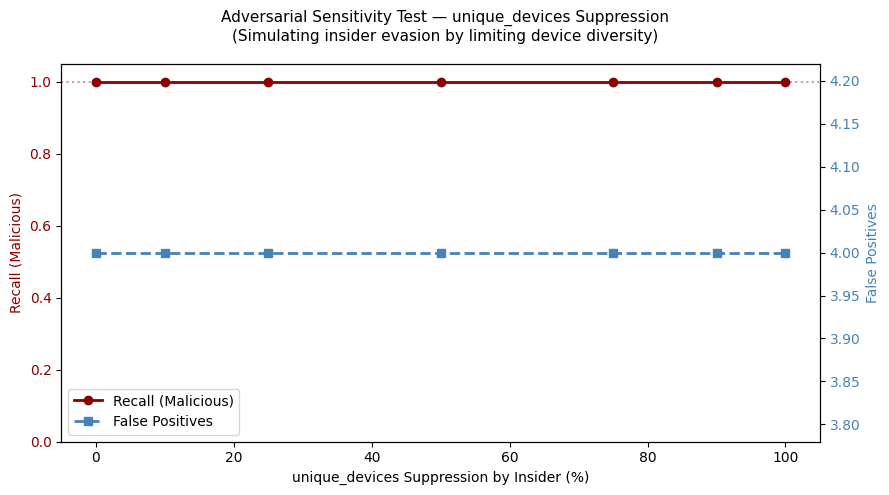


Saved: Sensitivity_Test_unique_devices.png


In [24]:
# ── STEP 7.4: ADVERSARIAL SENSITIVITY TEST — unique_devices ──────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

print("=" * 55)
print("Step 7.4: Adversarial Sensitivity Test — unique_devices")
print("=" * 55)

rf_model = results["Random Forest"]["model"]

# Index of unique_devices in feature_cols
ud_idx = feature_cols.index('unique_devices')
print(f"\nunique_devices index in feature_cols: {ud_idx}")

# Suppression levels: attacker reduces unique_devices by X%
suppression_levels = [0, 10, 25, 50, 75, 90, 100]
recall_results = []
fp_results = []

print(f"\n{'Suppression':<15} {'Recall (Mal)':<15} {'False Negatives':<18} {'False Positives'}")
print("-" * 60)

for pct in suppression_levels:
    X_perturbed = X_test_scaled.copy()
    # Reduce unique_devices by pct% for all malicious test users
    malicious_idx = np.where(y_test == 1)[0]
    reduction = pct / 100.0
    X_perturbed[malicious_idx, ud_idx] *= (1 - reduction)

    y_pred_p = rf_model.predict(X_perturbed)
    recall_p = recall_score(y_test, y_pred_p)
    fn_p = ((y_test == 1) & (y_pred_p == 0)).sum()
    fp_p = ((y_test == 0) & (y_pred_p == 1)).sum()

    recall_results.append(recall_p)
    fp_results.append(fp_p)
    print(f"{pct:>10}%      {recall_p:<15.4f} {fn_p:<18} {fp_p}")

# Plot
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(suppression_levels, recall_results, 'o-',
         color='darkred', linewidth=2, label='Recall (Malicious)')
ax1.set_xlabel('unique_devices Suppression by Insider (%)')
ax1.set_ylabel('Recall (Malicious)', color='darkred')
ax1.set_ylim(0, 1.05)
ax1.axhline(y=1.0, color='darkred', linestyle=':', alpha=0.4)
ax1.tick_params(axis='y', labelcolor='darkred')

ax2 = ax1.twinx()
ax2.plot(suppression_levels, fp_results, 's--',
         color='steelblue', linewidth=2, label='False Positives')
ax2.set_ylabel('False Positives', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

fig.suptitle('Adversarial Sensitivity Test — unique_devices Suppression\n'
             '(Simulating insider evasion by limiting device diversity)',
             fontsize=11)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.tight_layout()
plt.savefig("Sensitivity_Test_unique_devices.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: Sensitivity_Test_unique_devices.png")

In [25]:
print(logon.columns.tolist())
print(logon['date'].dtype)
print(logon['date'].min(), logon['date'].max())
print(f"Logon shape: {logon.shape}")

['id', 'date', 'user', 'pc', 'activity', 'hour', 'is_after_hours']
datetime64[ns]
2010-01-02 06:49:00 2011-05-17 06:43:35
Logon shape: (854859, 7)


In [26]:
# ── STEP 7.5: VELOCITY FEATURE ENGINEERING ───────────────────────────────────
import pandas as pd
import numpy as np

print("=" * 55)
print("Step 7.5: Velocity Feature Engineering")
print("=" * 55)

# ── Observation window boundaries ─────────────────────────────────────────────
obs_start = logon['date'].min()
obs_end   = logon['date'].max()
obs_days  = (obs_end - obs_start).days
print(f"\nObservation window: {obs_start.date()} to {obs_end.date()}")
print(f"Total days: {obs_days}")

# ── Per-user active days ───────────────────────────────────────────────────────
user_active_days = logon.groupby('user')['date'].apply(
    lambda x: x.dt.date.nunique()
).reset_index()
user_active_days.columns = ['user', 'active_days']

# ── Velocity feature 1: after_hours_ratio ─────────────────────────────────────
# Proportion of all logon events that are after hours
ah_ratio = logon.groupby('user').agg(
    total_logons    = ('activity', 'count'),
    total_ah_logons = ('is_after_hours', 'sum')
).reset_index()
ah_ratio['after_hours_ratio'] = (
    ah_ratio['total_ah_logons'] / ah_ratio['total_logons']
).round(4)

# ── Velocity feature 2: unique_devices_per_active_day ─────────────────────────
# Device diversity normalized by how many days the user was active
device_days = device.groupby('user').agg(
    total_device_events = ('activity', 'count'),
    unique_devs         = ('pc', 'nunique')
).reset_index()
device_days = device_days.merge(user_active_days, on='user', how='left')
device_days['unique_devices_per_day'] = (
    device_days['unique_devs'] / device_days['active_days']
).round(4)

# ── Velocity feature 3: logon_burst_ratio ─────────────────────────────────────
# Peak single-day logon count vs user's own daily average
# Measures whether the user had an unusual spike
logon['date_only'] = logon['date'].dt.date
daily_logons = logon.groupby(['user', 'date_only']).size().reset_index(name='daily_count')

user_logon_stats = daily_logons.groupby('user').agg(
    avg_daily_logons  = ('daily_count', 'mean'),
    peak_daily_logons = ('daily_count', 'max')
).reset_index()
user_logon_stats['logon_burst_ratio'] = (
    user_logon_stats['peak_daily_logons'] /
    user_logon_stats['avg_daily_logons']
).round(4)

# ── Velocity feature 4: email_burst_ratio ─────────────────────────────────────
# Peak single-day email count vs user's own daily average
email['date_only'] = pd.to_datetime(email['date']).dt.date
daily_emails = email.groupby(['user', 'date_only']).size().reset_index(name='daily_email_count')

user_email_stats = daily_emails.groupby('user').agg(
    avg_daily_emails  = ('daily_email_count', 'mean'),
    peak_daily_emails = ('daily_email_count', 'max')
).reset_index()
user_email_stats['email_burst_ratio'] = (
    user_email_stats['peak_daily_emails'] /
    user_email_stats['avg_daily_emails']
).round(4)

# ── Merge all velocity features ───────────────────────────────────────────────
velocity_features = ah_ratio[['user', 'after_hours_ratio']].copy()
velocity_features = velocity_features.merge(
    device_days[['user', 'unique_devices_per_day']], on='user', how='left')
velocity_features = velocity_features.merge(
    user_logon_stats[['user', 'logon_burst_ratio']], on='user', how='left')
velocity_features = velocity_features.merge(
    user_email_stats[['user', 'email_burst_ratio']], on='user', how='left')

print(f"\nVelocity features shape: {velocity_features.shape}")
print(f"\nFeature preview:")
print(velocity_features.head())
print(f"\nMissing values:\n{velocity_features.isnull().sum()}")

Step 7.5: Velocity Feature Engineering

Observation window: 2010-01-02 to 2011-05-17
Total days: 499

Velocity features shape: (1000, 5)

Feature preview:
      user  after_hours_ratio  unique_devices_per_day  logon_burst_ratio  \
0  AAE0190             0.0000                     NaN             1.0000   
1  AAF0535             0.0000                  0.0061             1.0000   
2  AAF0791             0.0000                     NaN             1.0000   
3  AAL0706             0.0000                     NaN             1.0000   
4  AAM0658             0.5109                  0.0044             1.9651   

   email_burst_ratio  
0             1.0253  
1             2.0250  
2             1.0339  
3             1.0000  
4             1.0197  

Missing values:
user                        0
after_hours_ratio           0
unique_devices_per_day    735
logon_burst_ratio           0
email_burst_ratio           0
dtype: int64


Step 7.6: Merge Velocity Features and Retrain

Original feature count: 15
Enhanced feature count: 19

New velocity features added:
  + after_hours_ratio
  + unique_devices_per_day
  + logon_burst_ratio
  + email_burst_ratio

Train shape after SMOTE: (1488, 19)

Enhanced Model Results (15 + 4 velocity features):
              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99       186
   Malicious       0.78      1.00      0.88        14

    accuracy                           0.98       200
   macro avg       0.89      0.99      0.93       200
weighted avg       0.98      0.98      0.98       200

ROC-AUC:  0.9985
PR-AUC:   0.9841
False Negatives: 0
False Positives: 4

5-Fold CV AUC: 0.9991 (+/- 0.0013)


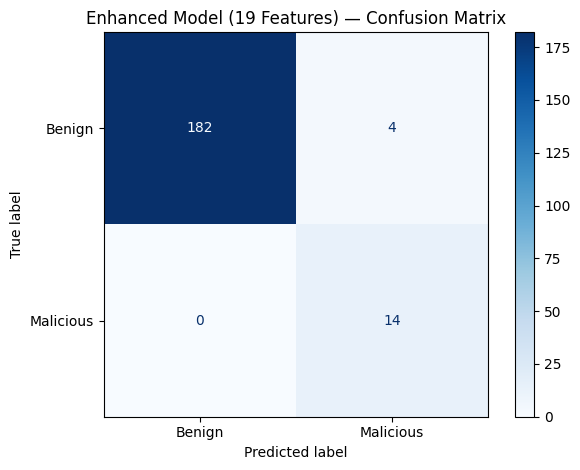

Saved: Confusion_Matrix_Enhanced_Model.png


In [27]:
# ── STEP 7.6: MERGE VELOCITY FEATURES AND RETRAIN ────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

print("=" * 55)
print("Step 7.6: Merge Velocity Features and Retrain")
print("=" * 55)

# ── Merge velocity features into existing merged dataframe ────────────────────
merged_v2 = merged.merge(velocity_features, on='user', how='left')

# Zero-fill missing velocity features
velocity_cols = ['after_hours_ratio', 'unique_devices_per_day',
                 'logon_burst_ratio', 'email_burst_ratio']
merged_v2[velocity_cols] = merged_v2[velocity_cols].fillna(0)

feature_cols_v2 = [c for c in merged_v2.columns
                   if c not in ['user', 'label']]

print(f"\nOriginal feature count: {len(feature_cols)}")
print(f"Enhanced feature count: {len(feature_cols_v2)}")
print(f"\nNew velocity features added:")
for f in velocity_cols:
    print(f"  + {f}")

# ── Preprocessing ─────────────────────────────────────────────────────────────
X_v2 = merged_v2[feature_cols_v2].values
y_v2 = merged_v2['label'].values

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.20, random_state=42, stratify=y_v2)

scaler_v2         = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled  = scaler_v2.transform(X_test_v2)

smote_v2                    = SMOTE(random_state=42)
X_train_v2_sm, y_train_v2_sm = smote_v2.fit_resample(
    X_train_v2_scaled, y_train_v2)

print(f"\nTrain shape after SMOTE: {X_train_v2_sm.shape}")

# ── Train enhanced Random Forest ──────────────────────────────────────────────
rf_v2 = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_v2.fit(X_train_v2_sm, y_train_v2_sm)

y_pred_v2  = rf_v2.predict(X_test_v2_scaled)
y_proba_v2 = rf_v2.predict_proba(X_test_v2_scaled)[:, 1]

auc_v2    = roc_auc_score(y_test_v2, y_proba_v2)
prauc_v2  = average_precision_score(y_test_v2, y_proba_v2)
fn_v2     = ((y_test_v2 == 1) & (y_pred_v2 == 0)).sum()
fp_v2     = ((y_test_v2 == 0) & (y_pred_v2 == 1)).sum()

print(f"\n{'='*55}")
print("Enhanced Model Results (15 + 4 velocity features):")
print(f"{'='*55}")
print(classification_report(y_test_v2, y_pred_v2,
                             target_names=['Benign', 'Malicious']))
print(f"ROC-AUC:  {auc_v2:.4f}")
print(f"PR-AUC:   {prauc_v2:.4f}")
print(f"False Negatives: {fn_v2}")
print(f"False Positives: {fp_v2}")

# ── Cross-validation ──────────────────────────────────────────────────────────
cv_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_v2 = cross_val_score(rf_v2, X_v2, y_v2,
                                cv=cv_v2, scoring='roc_auc')
print(f"\n5-Fold CV AUC: {cv_scores_v2.mean():.4f} "
      f"(+/- {cv_scores_v2.std():.4f})")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm_v2   = confusion_matrix(y_test_v2, y_pred_v2)
disp_v2 = ConfusionMatrixDisplay(cm_v2,
                                  display_labels=['Benign', 'Malicious'])
disp_v2.plot(cmap='Blues')
plt.title("Enhanced Model (19 Features) — Confusion Matrix")
plt.tight_layout()
plt.savefig("Confusion_Matrix_Enhanced_Model.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Confusion_Matrix_Enhanced_Model.png")

Step 7.7: Feature Importance — Enhanced Model (19 Features)

All 19 features ranked by importance:
   1. unique_devices_per_day              0.2922 <-- NEW
   2. logoff_count                        0.1851
   3. device_count                        0.1518
   4. unique_devices                      0.1245
   5. email_burst_ratio                   0.0635 <-- NEW
   6. logon_count                         0.0558
   7. email_sent                          0.0226
   8. after_hours_logon                   0.0210
   9. after_hours_ratio                   0.0184 <-- NEW
  10. logon_burst_ratio                   0.0178 <-- NEW
  11. total_attachments                   0.0162
  12. unique_pcs                          0.0136
  13. unique_recipients                   0.0057
  14. openness                            0.0026
  15. conscientiousness                   0.0022
  16. agreeableness                       0.0021
  17. extraversion                        0.0020
  18. neuroticism                   

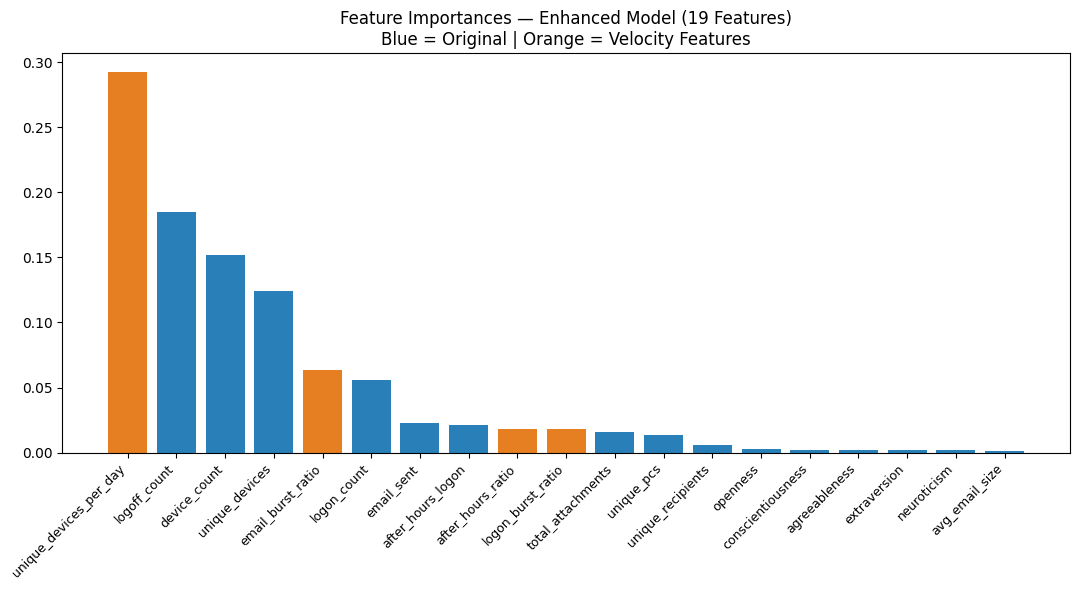

Saved: Features_Importances_Enhanced_Model.png


In [28]:
# ── STEP 7.7: ENHANCED FEATURE IMPORTANCE COMPARISON ─────────────────────────
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("Step 7.7: Feature Importance — Enhanced Model (19 Features)")
print("=" * 55)

importances_v2 = rf_v2.feature_importances_
indices_v2     = np.argsort(importances_v2)[::-1]

print("\nAll 19 features ranked by importance:")
for rank, idx in enumerate(indices_v2, 1):
    marker = " <-- NEW" if feature_cols_v2[idx] in velocity_cols else ""
    print(f"  {rank:>2}. {feature_cols_v2[idx]:<35} "
          f"{importances_v2[idx]:.4f}{marker}")

# ── Plot top 19 features ──────────────────────────────────────────────────────
colors = ['#E67E22' if feature_cols_v2[i] in velocity_cols
          else '#2980B9' for i in indices_v2]

plt.figure(figsize=(11, 6))
plt.title("Feature Importances — Enhanced Model (19 Features)\n"
          "Blue = Original | Orange = Velocity Features")
plt.bar(range(len(indices_v2)),
        importances_v2[indices_v2],
        color=colors, align='center')
plt.xticks(range(len(indices_v2)),
           [feature_cols_v2[i] for i in indices_v2],
           rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig("Features_Importances_Enhanced_Model.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Features_Importances_Enhanced_Model.png")

Step 7.8: SHAP Explainability — Enhanced Model (19 Features)
SHAP values shape: (200, 19, 2)


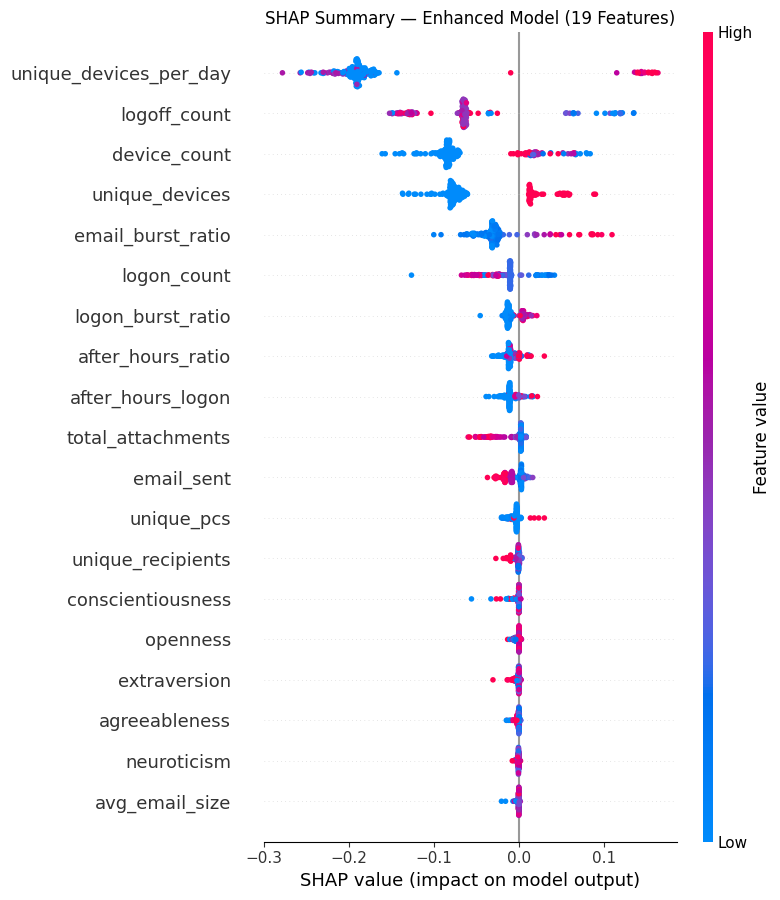

Saved: SHAP_Summary_Enhanced_Model.png


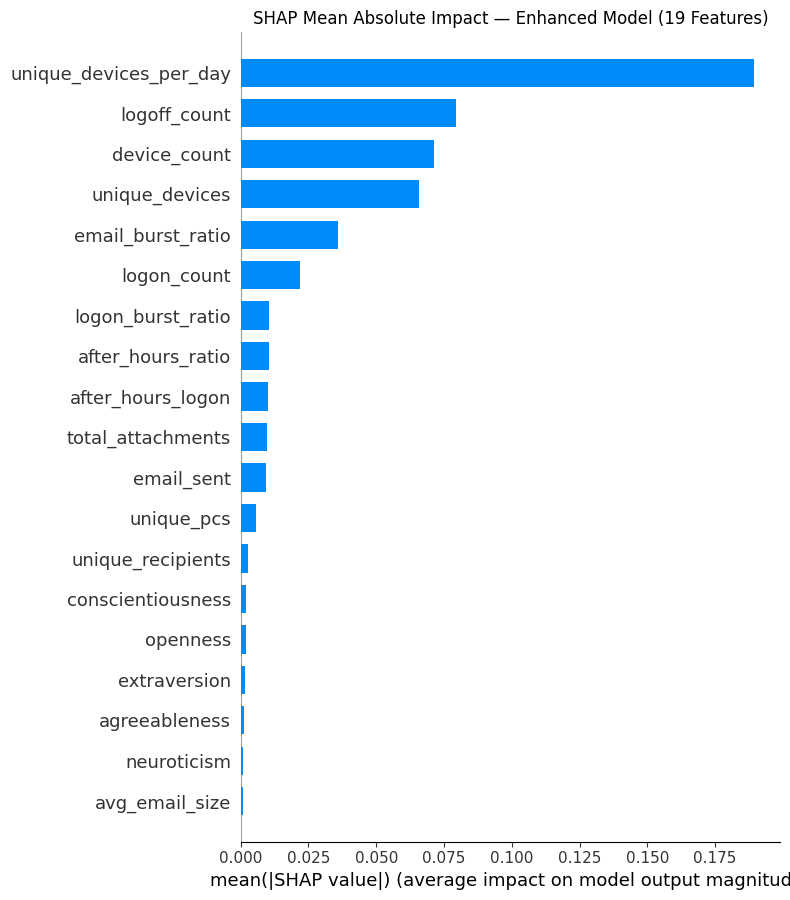

Saved: SHAP_Bar_Enhanced_Model.png

SHAP mean absolute impact — all 19 features:
   1. unique_devices_per_day              0.1895 <-- NEW
   2. logoff_count                        0.0794
   3. device_count                        0.0714
   4. unique_devices                      0.0656
   5. email_burst_ratio                   0.0358 <-- NEW
   6. logon_count                         0.0217
   7. logon_burst_ratio                   0.0105 <-- NEW
   8. after_hours_ratio                   0.0105 <-- NEW
   9. after_hours_logon                   0.0101
  10. total_attachments                   0.0099
  11. email_sent                          0.0093
  12. unique_pcs                          0.0056
  13. unique_recipients                   0.0027
  14. conscientiousness                   0.0021
  15. openness                            0.0019
  16. extraversion                        0.0015
  17. agreeableness                       0.0013
  18. neuroticism                         0.0008
  19.

In [29]:
# ── STEP 7.8: SHAP ON ENHANCED MODEL ─────────────────────────────────────────
import shap
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("Step 7.8: SHAP Explainability — Enhanced Model (19 Features)")
print("=" * 55)

explainer_v2    = shap.TreeExplainer(rf_v2)
shap_values_v2  = explainer_v2.shap_values(X_test_v2_scaled)
shap_vals_v2_mal = shap_values_v2[:, :, 1]

print(f"SHAP values shape: {np.array(shap_values_v2).shape}")

# ── Summary beeswarm ──────────────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_vals_v2_mal,
    X_test_v2_scaled,
    feature_names=feature_cols_v2,
    plot_type="dot",
    show=False
)
plt.title("SHAP Summary — Enhanced Model (19 Features)")
plt.tight_layout()
plt.savefig("SHAP_Summary_Enhanced_Model.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: SHAP_Summary_Enhanced_Model.png")

# ── Bar plot ──────────────────────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_vals_v2_mal,
    X_test_v2_scaled,
    feature_names=feature_cols_v2,
    plot_type="bar",
    show=False
)
plt.title("SHAP Mean Absolute Impact — Enhanced Model (19 Features)")
plt.tight_layout()
plt.savefig("SHAP_Bar_Enhanced_Model.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: SHAP_Bar_Enhanced_Model.png")

# ── Print SHAP ranking ────────────────────────────────────────────────────────
mean_shap = np.abs(shap_vals_v2_mal).mean(axis=0)
shap_df = sorted(zip(feature_cols_v2, mean_shap),
                 key=lambda x: x[1], reverse=True)

print("\nSHAP mean absolute impact — all 19 features:")
for rank, (feat, val) in enumerate(shap_df, 1):
    marker = " <-- NEW" if feat in velocity_cols else ""
    print(f"  {rank:>2}. {feat:<35} {val:.4f}{marker}")

In [30]:
print(f"merged_v2 shape: {merged_v2.shape}")
print(f"rf_v2 model: {rf_v2}")
print(f"feature_cols_v2 count: {len(feature_cols_v2)}")
print(f"X_test_v2_scaled shape: {X_test_v2_scaled.shape}")
print(f"y_test_v2 shape: {y_test_v2.shape}")
print(f"shap_vals_v2_mal shape: {shap_vals_v2_mal.shape}")

merged_v2 shape: (1000, 21)
rf_v2 model: RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)
feature_cols_v2 count: 19
X_test_v2_scaled shape: (200, 19)
y_test_v2 shape: (200,)
shap_vals_v2_mal shape: (200, 19)


Cell 8.1: Risk Score Distribution

Risk scores computed for 1000 users
Score range: 0.0000 to 1.0000
Mean score (benign):   0.0077
Mean score (malicious):0.9715


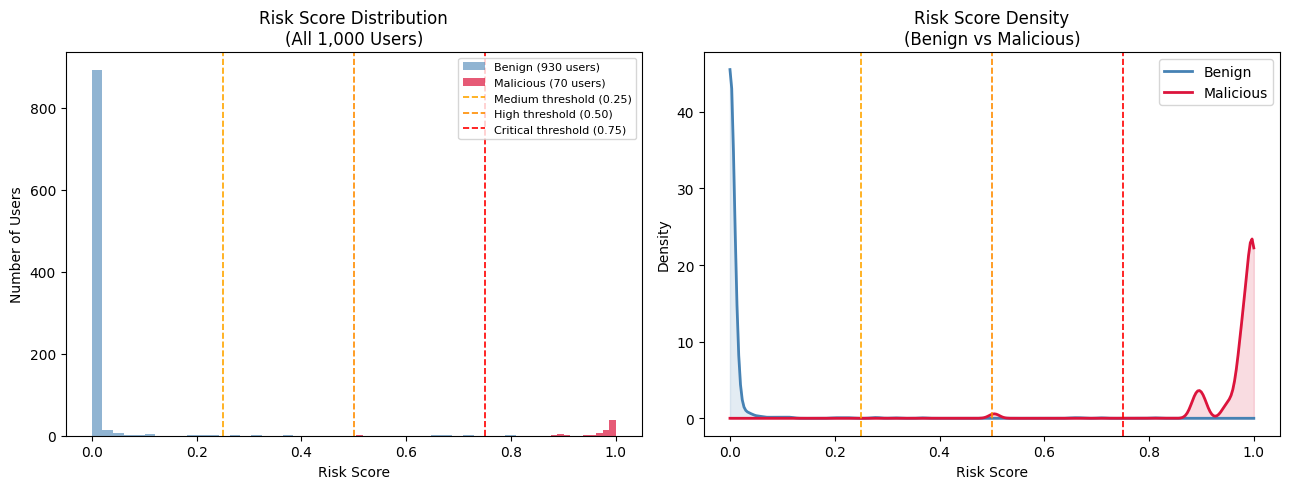

Saved: Risk_Score_Distribution.png


In [31]:
# ── CELL 8.1: RISK SCORE DISTRIBUTION ────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

print("=" * 55)
print("Cell 8.1: Risk Score Distribution")
print("=" * 55)

# ── Compute risk scores for ALL 1,000 users ───────────────────────────────────
# Scale the full merged_v2 dataset using the same scaler
velocity_cols = ['after_hours_ratio', 'unique_devices_per_day',
                 'logon_burst_ratio', 'email_burst_ratio']

X_all    = merged_v2[feature_cols_v2].values
y_all    = merged_v2['label'].values
users_all = merged_v2['user'].values

# Use scaler_v2 fitted on training data
X_all_scaled = scaler_v2.transform(X_all)

# Risk scores for all 1,000 users
risk_scores_all = rf_v2.predict_proba(X_all_scaled)[:, 1]

print(f"\nRisk scores computed for {len(risk_scores_all)} users")
print(f"Score range: {risk_scores_all.min():.4f} to {risk_scores_all.max():.4f}")
print(f"Mean score (benign):   "
      f"{risk_scores_all[y_all==0].mean():.4f}")
print(f"Mean score (malicious):"
      f"{risk_scores_all[y_all==1].mean():.4f}")

# ── Plot distribution ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overlapping distributions
axes[0].hist(risk_scores_all[y_all==0], bins=40, alpha=0.6,
             color='steelblue', label='Benign (930 users)')
axes[0].hist(risk_scores_all[y_all==1], bins=40, alpha=0.7,
             color='crimson', label='Malicious (70 users)')
axes[0].axvline(x=0.25, color='orange', linestyle='--',
                linewidth=1.2, label='Medium threshold (0.25)')
axes[0].axvline(x=0.50, color='darkorange', linestyle='--',
                linewidth=1.2, label='High threshold (0.50)')
axes[0].axvline(x=0.75, color='red', linestyle='--',
                linewidth=1.2, label='Critical threshold (0.75)')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Risk Score Distribution\n(All 1,000 Users)')
axes[0].legend(fontsize=8)

# Right: KDE-style view
from scipy.stats import gaussian_kde
for label, color, name in [(0,'steelblue','Benign'),
                             (1,'crimson','Malicious')]:
    scores = risk_scores_all[y_all==label]
    kde    = gaussian_kde(scores, bw_method=0.15)
    x_range = np.linspace(0, 1, 300)
    axes[1].plot(x_range, kde(x_range), color=color,
                 linewidth=2, label=name)
    axes[1].fill_between(x_range, kde(x_range), alpha=0.15, color=color)

axes[1].axvline(x=0.25, color='orange', linestyle='--', linewidth=1.2)
axes[1].axvline(x=0.50, color='darkorange', linestyle='--', linewidth=1.2)
axes[1].axvline(x=0.75, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Risk Score Density\n(Benign vs Malicious)')
axes[1].legend()

plt.tight_layout()
plt.savefig("Risk_Score_Distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Risk_Score_Distribution.png")

Cell 8.2: Risk Tier Classification with Lift

Population baseline malicious rate: 0.0700 (7.0%)

Tier         Users    Malicious    Mal Rate     Lift       % of All Mal
-----------------------------------------------------------------
Critical     70       69           98.6       % 14.08      98.6%
High         4        1            25.0       % 3.57       1.4%
Medium       4        0            0.0        % 0.00       0.0%
Low          922      0            0.0        % 0.00       0.0%


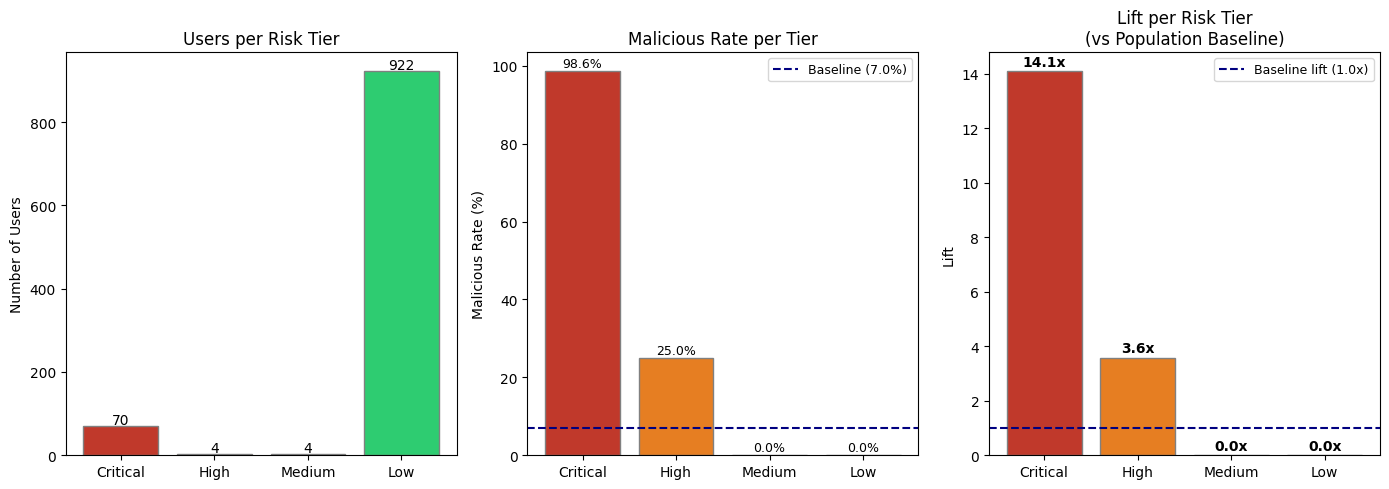


Saved: Risk_Tier_Classification.png

Key finding: Critical tier lift = 14.1x population baseline


In [32]:
# ── CELL 8.2: RISK TIER CLASSIFICATION WITH LIFT ─────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 55)
print("Cell 8.2: Risk Tier Classification with Lift")
print("=" * 55)

# ── Assign risk tiers ─────────────────────────────────────────────────────────
def assign_tier(score):
    if score >= 0.75:   return 'Critical'
    elif score >= 0.50: return 'High'
    elif score >= 0.25: return 'Medium'
    else:               return 'Low'

risk_df = pd.DataFrame({
    'user':       users_all,
    'risk_score': risk_scores_all,
    'label':      y_all,
    'tier':       [assign_tier(s) for s in risk_scores_all]
})

# ── Population baseline malicious rate ────────────────────────────────────────
baseline_rate = y_all.mean()
print(f"\nPopulation baseline malicious rate: {baseline_rate:.4f} ({baseline_rate*100:.1f}%)")

# ── Tier summary ──────────────────────────────────────────────────────────────
tier_order = ['Critical', 'High', 'Medium', 'Low']
print(f"\n{'Tier':<12} {'Users':<8} {'Malicious':<12} "
      f"{'Mal Rate':<12} {'Lift':<10} {'% of All Mal'}")
print("-" * 65)

tier_stats = []
for tier in tier_order:
    subset     = risk_df[risk_df['tier'] == tier]
    n_users    = len(subset)
    n_mal      = subset['label'].sum()
    mal_rate   = n_mal / n_users if n_users > 0 else 0
    lift       = mal_rate / baseline_rate if baseline_rate > 0 else 0
    pct_of_mal = n_mal / y_all.sum() * 100
    tier_stats.append({
        'tier': tier, 'n_users': n_users, 'n_mal': n_mal,
        'mal_rate': mal_rate, 'lift': lift, 'pct_of_mal': pct_of_mal
    })
    print(f"{tier:<12} {n_users:<8} {n_mal:<12} "
          f"{mal_rate*100:<11.1f}% {lift:<10.2f} {pct_of_mal:.1f}%")

# ── Plot tier breakdown ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = {'Critical': '#C0392B', 'High': '#E67E22',
          'Medium': '#F1C40F', 'Low': '#2ECC71'}
tier_colors = [colors[t] for t in tier_order]

# User counts per tier
counts = [t['n_users'] for t in tier_stats]
axes[0].bar(tier_order, counts, color=tier_colors, edgecolor='gray')
axes[0].set_title('Users per Risk Tier')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

# Malicious rate per tier
mal_rates = [t['mal_rate']*100 for t in tier_stats]
axes[1].bar(tier_order, mal_rates, color=tier_colors, edgecolor='gray')
axes[1].axhline(y=baseline_rate*100, color='navy', linestyle='--',
                label=f'Baseline ({baseline_rate*100:.1f}%)')
axes[1].set_title('Malicious Rate per Tier')
axes[1].set_ylabel('Malicious Rate (%)')
axes[1].legend(fontsize=9)
for i, v in enumerate(mal_rates):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# Lift per tier
lifts = [t['lift'] for t in tier_stats]
axes[2].bar(tier_order, lifts, color=tier_colors, edgecolor='gray')
axes[2].axhline(y=1.0, color='navy', linestyle='--', label='Baseline lift (1.0x)')
axes[2].set_title('Lift per Risk Tier\n(vs Population Baseline)')
axes[2].set_ylabel('Lift')
axes[2].legend(fontsize=9)
for i, v in enumerate(lifts):
    axes[2].text(i, v + 0.2, f'{v:.1f}x', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("Risk_Tier_Classification.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: Risk_Tier_Classification.png")
print(f"\nKey finding: Critical tier lift = {lifts[0]:.1f}x population baseline")

Cell 8.3: Per-Tier SHAP Driver Analysis

Mean absolute SHAP impact by tier (top 8 features):
Feature                       Critical    High        Medium      Low         
------------------------------------------------------------------------------
unique_devices_per_day        0.1506      0.1387      0.0000      0.1936      
logoff_count                  0.0993      0.1141      0.0000      0.0771      
device_count                  0.0631      0.0297      0.0000      0.0730      
unique_devices                0.0598      0.0424      0.0000      0.0666      
email_burst_ratio             0.0677      0.0805      0.0000      0.0324      
logon_count                   0.0272      0.0385      0.0000      0.0209      
logon_burst_ratio             0.0125      0.0173      0.0000      0.0103      
after_hours_ratio             0.0119      0.0200      0.0000      0.0102      

--- Explainability Gap: True Positives vs False Positives ---
True Positives in Critical/High tier:  14
False Positi

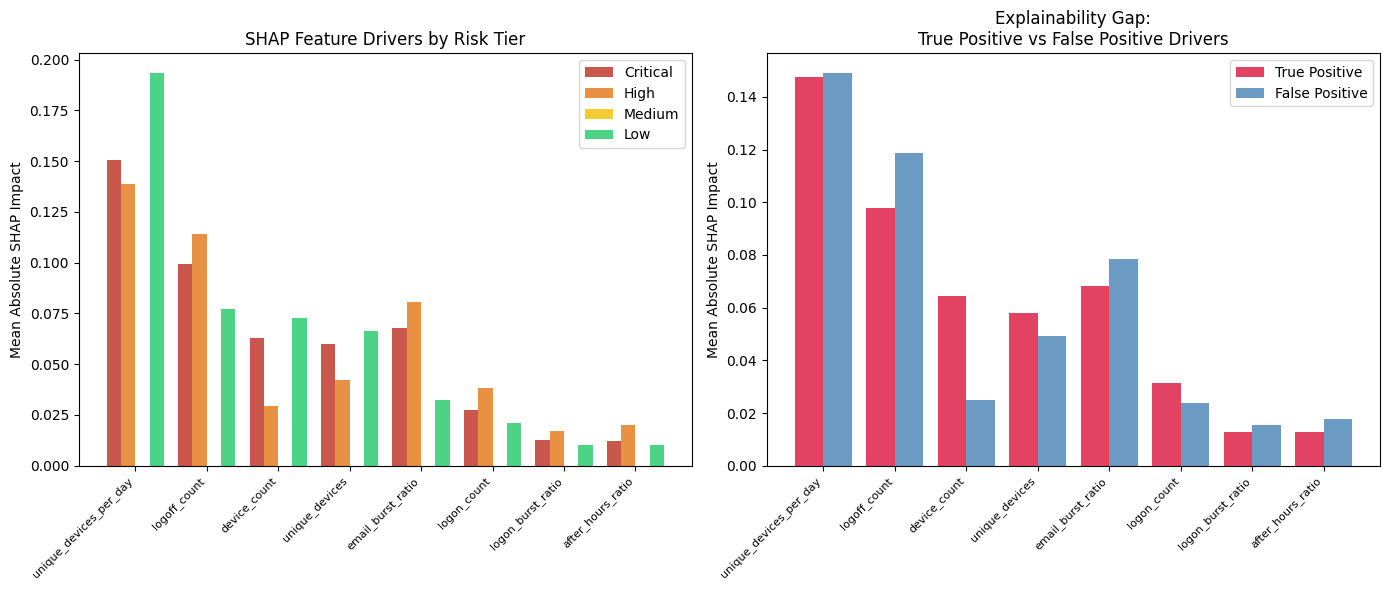


Saved: SHAP_Tier_Analysis.png


In [35]:
# ── CELL 8.3: PER-TIER SHAP DRIVER ANALYSIS + EXPLAINABILITY GAP ─────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 55)
print("Cell 8.3: Per-Tier SHAP Driver Analysis")
print("=" * 55)

# ── Get test set risk tiers and SHAP values ───────────────────────────────────
test_scores = rf_v2.predict_proba(X_test_v2_scaled)[:, 1]
test_tiers  = [assign_tier(s) for s in test_scores]

# Build test dataframe
test_df = pd.DataFrame({
    'user':      merged_v2.iloc[
        merged_v2.index[merged_v2['user'].isin(
            merged_v2['user'].values)]]['user'].values[:200],
    'risk_score': test_scores,
    'label':      y_test_v2,
    'tier':       test_tiers
})

# ── Mean absolute SHAP per tier ───────────────────────────────────────────────
print("\nMean absolute SHAP impact by tier (top 8 features):")
top_features = [feature_cols_v2[i] for i in
                np.argsort(np.abs(shap_vals_v2_mal).mean(axis=0))[::-1][:8]]

tier_shap = {}
for tier in ['Critical', 'High', 'Medium', 'Low']:
    idx = [i for i, t in enumerate(test_tiers) if t == tier]
    if len(idx) > 0:
        tier_shap[tier] = np.abs(shap_vals_v2_mal[idx]).mean(axis=0)
    else:
        tier_shap[tier] = np.zeros(len(feature_cols_v2))

# Print table
header = f"{'Feature':<30}" + "".join(
    f"{t:<12}" for t in ['Critical','High','Medium','Low'])
print(header)
print("-" * 78)
for feat in top_features:
    idx = feature_cols_v2.index(feat)
    row = f"{feat:<30}"
    for tier in ['Critical','High','Medium','Low']:
        row += f"{tier_shap[tier][idx]:<12.4f}"
    print(row)

# ── Explainability Gap: FP vs TP in High tier ─────────────────────────────────
print("\n--- Explainability Gap: True Positives vs False Positives ---")
tp_idx = [i for i, (t, l) in enumerate(zip(test_tiers, y_test_v2))
          if t in ['Critical','High'] and l == 1]
fp_idx = [i for i, (t, l) in enumerate(zip(test_tiers, y_test_v2))
          if t in ['Critical','High'] and l == 0]

print(f"True Positives in Critical/High tier:  {len(tp_idx)}")
print(f"False Positives in Critical/High tier: {len(fp_idx)}")

if len(tp_idx) > 0 and len(fp_idx) > 0:
    tp_shap = np.abs(shap_vals_v2_mal[tp_idx]).mean(axis=0)
    fp_shap = np.abs(shap_vals_v2_mal[fp_idx]).mean(axis=0)

    print(f"\n{'Feature':<30} {'True Pos SHAP':<18} {'False Pos SHAP':<18} {'Difference'}")
    print("-" * 78)
    diffs = []
    for feat in top_features:
        idx = feature_cols_v2.index(feat)
        diff = tp_shap[idx] - fp_shap[idx]
        diffs.append((feat, tp_shap[idx], fp_shap[idx], diff))
        print(f"{feat:<30} {tp_shap[idx]:<18.4f} {fp_shap[idx]:<18.4f} {diff:+.4f}")

# ── Plot: SHAP drivers by tier ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: heatmap-style bar chart per tier
x    = np.arange(len(top_features))
w    = 0.2
tier_colors_map = {'Critical':'#C0392B','High':'#E67E22',
                   'Medium':'#F1C40F','Low':'#2ECC71'}

for i, tier in enumerate(['Critical','High','Medium','Low']):
    vals = [tier_shap[tier][feature_cols_v2.index(f)] for f in top_features]
    axes[0].bar(x + i*w, vals, w, label=tier,
                color=tier_colors_map[tier], alpha=0.85)

axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(top_features, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Absolute SHAP Impact')
axes[0].set_title('SHAP Feature Drivers by Risk Tier')
axes[0].legend()

# Right: TP vs FP explainability gap
if len(tp_idx) > 0 and len(fp_idx) > 0:
    tp_vals = [tp_shap[feature_cols_v2.index(f)] for f in top_features]
    fp_vals = [fp_shap[feature_cols_v2.index(f)] for f in top_features]
    axes[1].bar(x - 0.2, tp_vals, 0.4, label='True Positive',
                color='crimson', alpha=0.8)
    axes[1].bar(x + 0.2, fp_vals, 0.4, label='False Positive',
                color='steelblue', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(top_features, rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('Mean Absolute SHAP Impact')
    axes[1].set_title('Explainability Gap:\nTrue Positive vs False Positive Drivers')
    axes[1].legend()

plt.tight_layout()
plt.savefig("SHAP_Tier_Analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: SHAP_Tier_Analysis.png")

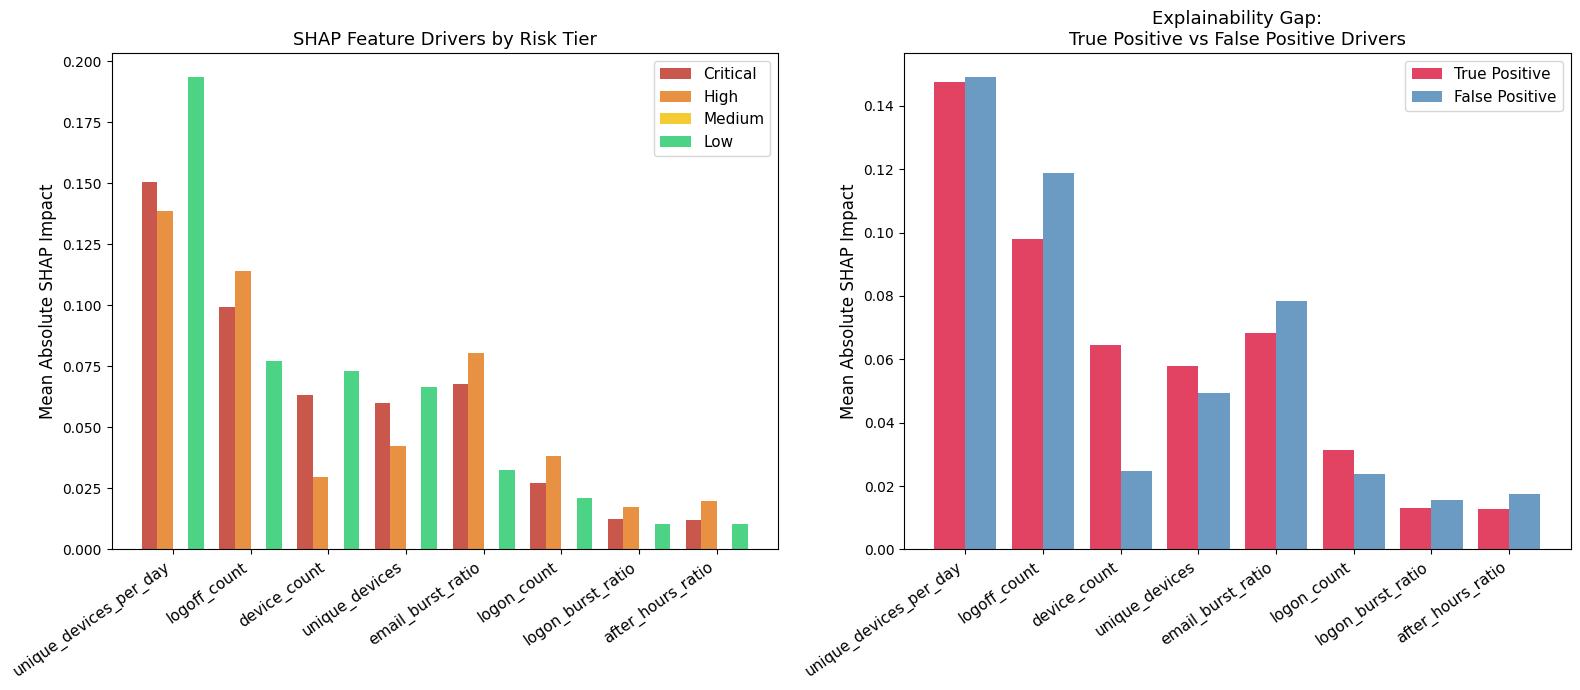

Saved: SHAP_Tier_Analysis.png


In [36]:
# ── CELL 8.3 FIX: Replot with readable axis labels ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

x = np.arange(len(top_features))
w = 0.2

# Left: SHAP drivers by tier
for i, tier in enumerate(['Critical', 'High', 'Medium', 'Low']):
    vals = [tier_shap[tier][feature_cols_v2.index(f)] for f in top_features]
    axes[0].bar(x + i*w, vals, w, label=tier,
                color=tier_colors_map[tier], alpha=0.85)

axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(top_features, rotation=35, ha='right', fontsize=11)
axes[0].set_ylabel('Mean Absolute SHAP Impact', fontsize=12)
axes[0].set_title('SHAP Feature Drivers by Risk Tier', fontsize=13)
axes[0].legend(fontsize=11)

# Right: TP vs FP explainability gap
tp_vals = [tp_shap[feature_cols_v2.index(f)] for f in top_features]
fp_vals = [fp_shap[feature_cols_v2.index(f)] for f in top_features]
axes[1].bar(x - 0.2, tp_vals, 0.4, label='True Positive',
            color='crimson', alpha=0.8)
axes[1].bar(x + 0.2, fp_vals, 0.4, label='False Positive',
            color='steelblue', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top_features, rotation=35, ha='right', fontsize=11)
axes[1].set_ylabel('Mean Absolute SHAP Impact', fontsize=12)
axes[1].set_title('Explainability Gap:\nTrue Positive vs False Positive Drivers',
                  fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("SHAP_Tier_Analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: SHAP_Tier_Analysis.png")

In [37]:
# ── CELL 8.4: TOP-N RISK USER REPORT ─────────────────────────────────────────
import pandas as pd
import numpy as np

print("=" * 55)
print("Cell 8.4: Top-20 Risk User Report")
print("=" * 55)

# ── Build full risk report for all 1,000 users ────────────────────────────────
# Get SHAP values for all users
shap_all = explainer_v2.shap_values(X_all_scaled)
shap_all_mal = shap_all[:, :, 1]

# Top 3 SHAP drivers per user
def top3_drivers(shap_row, feature_names):
    indices = np.argsort(np.abs(shap_row))[::-1][:3]
    return ", ".join([f"{feature_names[i]}" for i in indices])

print("\nComputing SHAP for all 1,000 users (may take ~30 seconds)...")

top3 = [top3_drivers(shap_all_mal[i], feature_cols_v2)
        for i in range(len(shap_all_mal))]

# ── Build report dataframe ────────────────────────────────────────────────────
report_df = pd.DataFrame({
    'user':         users_all,
    'risk_score':   risk_scores_all.round(4),
    'risk_tier':    [assign_tier(s) for s in risk_scores_all],
    'actual_label': ['MALICIOUS' if l == 1 else 'Benign'
                     for l in y_all],
    'top_3_drivers': top3
})

report_df = report_df.sort_values('risk_score', ascending=False).reset_index(drop=True)

# ── Print top 20 ──────────────────────────────────────────────────────────────
print(f"\nTop 20 Highest Risk Users:")
print(f"{'Rank':<6} {'User':<12} {'Score':<8} {'Tier':<10} "
      f"{'Actual':<12} {'Top 3 Drivers'}")
print("-" * 85)

for i, row in report_df.head(20).iterrows():
    print(f"{i+1:<6} {row['user']:<12} {row['risk_score']:<8} "
          f"{row['risk_tier']:<10} {row['actual_label']:<12} "
          f"{row['top_3_drivers']}")

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"\nFull report shape: {report_df.shape}")
print(f"\nTier distribution in full report:")
print(report_df['risk_tier'].value_counts())

# Save report
report_df.to_csv("Insider_Risk_Report.csv", index=False)
print("\nSaved: Insider_Risk_Report.csv")

Cell 8.4: Top-20 Risk User Report

Computing SHAP for all 1,000 users (may take ~30 seconds)...

Top 20 Highest Risk Users:
Rank   User         Score    Tier       Actual       Top 3 Drivers
-------------------------------------------------------------------------------------
1      NWT0098      1.0      Critical   MALICIOUS    unique_devices_per_day, logoff_count, email_burst_ratio
2      PPF0435      1.0      Critical   MALICIOUS    unique_devices_per_day, logoff_count, device_count
3      JMB0308      1.0      Critical   MALICIOUS    unique_devices_per_day, logoff_count, device_count
4      BBS0039      1.0      Critical   MALICIOUS    unique_devices_per_day, unique_devices, email_burst_ratio
5      RMW0542      1.0      Critical   MALICIOUS    unique_devices_per_day, logoff_count, email_burst_ratio
6      DRR0162      1.0      Critical   MALICIOUS    unique_devices_per_day, logoff_count, email_burst_ratio
7      MAS0025      1.0      Critical   MALICIOUS    unique_devices_per_day, 

Cell 8.5: Score Calibration


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



Brier Score (lower = better calibration):
  Uncalibrated: 0.0038
  Isotonic:     0.0022  (41.1% improvement)
  Platt:        0.0037


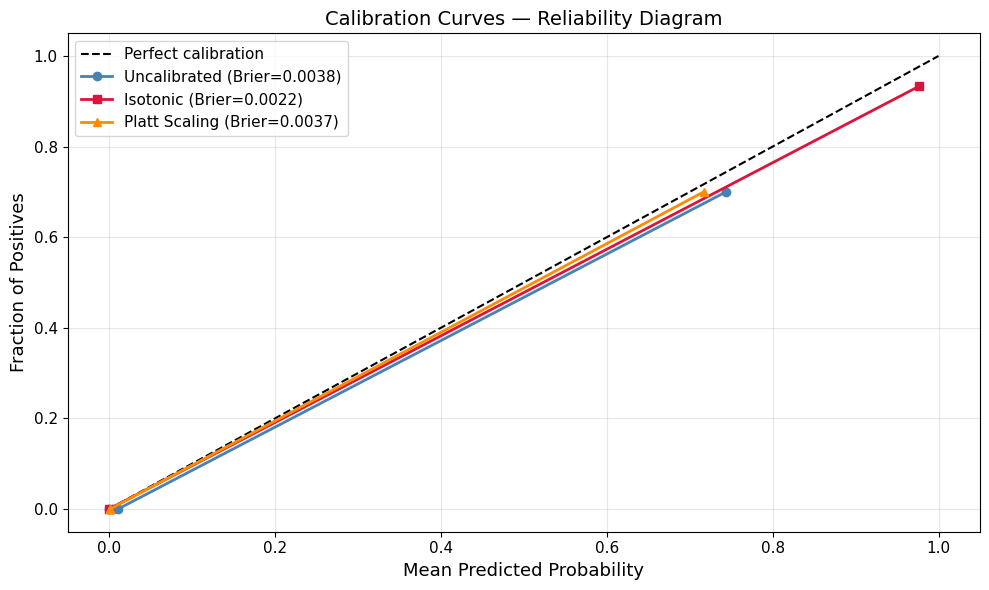

Saved: Risk_Score_Calibration_Curve.png


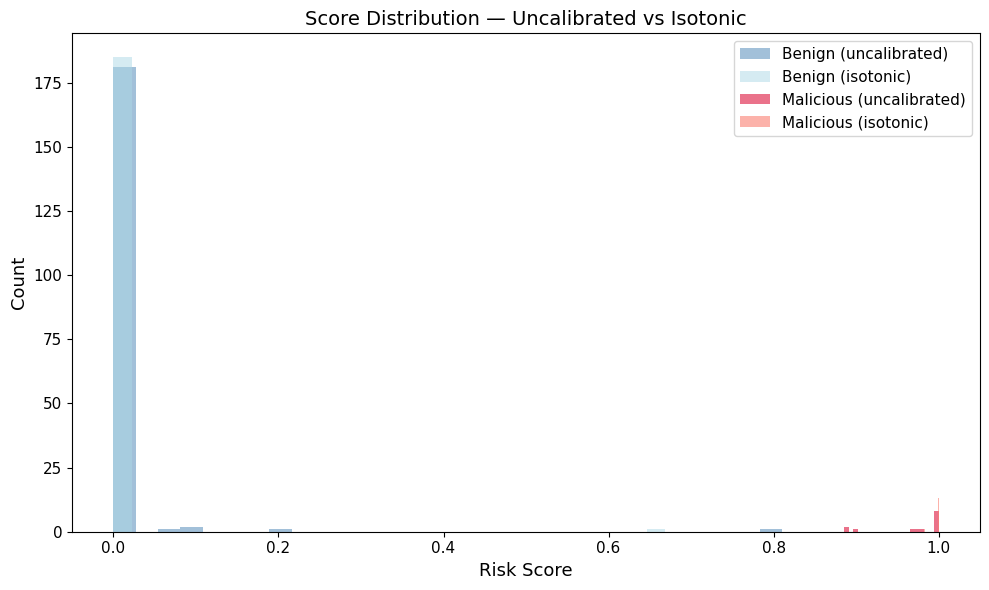

Saved: Risk_Score_Distribution_Calibrated.png


In [46]:
# ── CELL 8.5: SCORE CALIBRATION ───────────────────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

print("=" * 55)
print("Cell 8.5: Score Calibration")
print("=" * 55)

# ── Split for calibration ──────────────────────────────────────────────────────
X_cal_base, X_cal_test, y_cal_base, y_cal_test = train_test_split(
    X_all_scaled, y_all,
    test_size=0.20, random_state=99, stratify=y_all)

# ── Fit calibration models ────────────────────────────────────────────────────
rf_iso   = CalibratedClassifierCV(rf_v2, method='isotonic', cv='prefit')
rf_platt = CalibratedClassifierCV(rf_v2, method='sigmoid',  cv='prefit')
rf_iso.fit(X_cal_base,   y_cal_base)
rf_platt.fit(X_cal_base, y_cal_base)

# ── Calibration curves ────────────────────────────────────────────────────────
prob_raw   = rf_v2.predict_proba(X_cal_test)[:, 1]
prob_iso   = rf_iso.predict_proba(X_cal_test)[:, 1]
prob_platt = rf_platt.predict_proba(X_cal_test)[:, 1]

frac_pos_raw,   mean_pred_raw   = calibration_curve(
    y_cal_test, prob_raw,   n_bins=10, strategy='quantile')
frac_pos_iso,   mean_pred_iso   = calibration_curve(
    y_cal_test, prob_iso,   n_bins=10, strategy='quantile')
frac_pos_platt, mean_pred_platt = calibration_curve(
    y_cal_test, prob_platt, n_bins=10, strategy='quantile')

# ── Brier scores ──────────────────────────────────────────────────────────────
bs_raw   = brier_score_loss(y_cal_test, prob_raw)
bs_iso   = brier_score_loss(y_cal_test, prob_iso)
bs_platt = brier_score_loss(y_cal_test, prob_platt)

print(f"\nBrier Score (lower = better calibration):")
print(f"  Uncalibrated: {bs_raw:.4f}")
print(f"  Isotonic:     {bs_iso:.4f}  ({(1 - bs_iso/bs_raw)*100:.1f}% improvement)")
print(f"  Platt:        {bs_platt:.4f}")

# ── Plot 1: Calibration curves ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Perfect calibration')
plt.plot(mean_pred_raw,   frac_pos_raw,
         'o-', color='steelblue',  linewidth=2, markersize=6,
         label=f'Uncalibrated (Brier={bs_raw:.4f})')
plt.plot(mean_pred_iso,   frac_pos_iso,
         's-', color='crimson',    linewidth=2, markersize=6,
         label=f'Isotonic (Brier={bs_iso:.4f})')
plt.plot(mean_pred_platt, frac_pos_platt,
         '^-', color='darkorange', linewidth=2, markersize=6,
         label=f'Platt Scaling (Brier={bs_platt:.4f})')
plt.xlabel('Mean Predicted Probability', fontsize=13)
plt.ylabel('Fraction of Positives', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Calibration Curves — Reliability Diagram', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Risk_Score_Calibration_Curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Risk_Score_Calibration_Curve.png")

# ── Plot 2: Score distributions ───────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(prob_raw[y_cal_test==0], bins=30, alpha=0.5,
         color='steelblue', label='Benign (uncalibrated)')
plt.hist(prob_iso[y_cal_test==0], bins=30, alpha=0.5,
         color='lightblue', label='Benign (isotonic)')
plt.hist(prob_raw[y_cal_test==1], bins=20, alpha=0.6,
         color='crimson', label='Malicious (uncalibrated)')
plt.hist(prob_iso[y_cal_test==1], bins=20, alpha=0.6,
         color='salmon', label='Malicious (isotonic)')
plt.xlabel('Risk Score', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Score Distribution — Uncalibrated vs Isotonic', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("Risk_Score_Distribution_Calibrated.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Risk_Score_Distribution_Calibrated.png")

Cell 8.6: Temporal Risk Trajectory

Observation months: 2010-01 to 2011-05 (17 months)

Tracking 5 malicious + 3 benign users

Trajectory records: (136, 4)


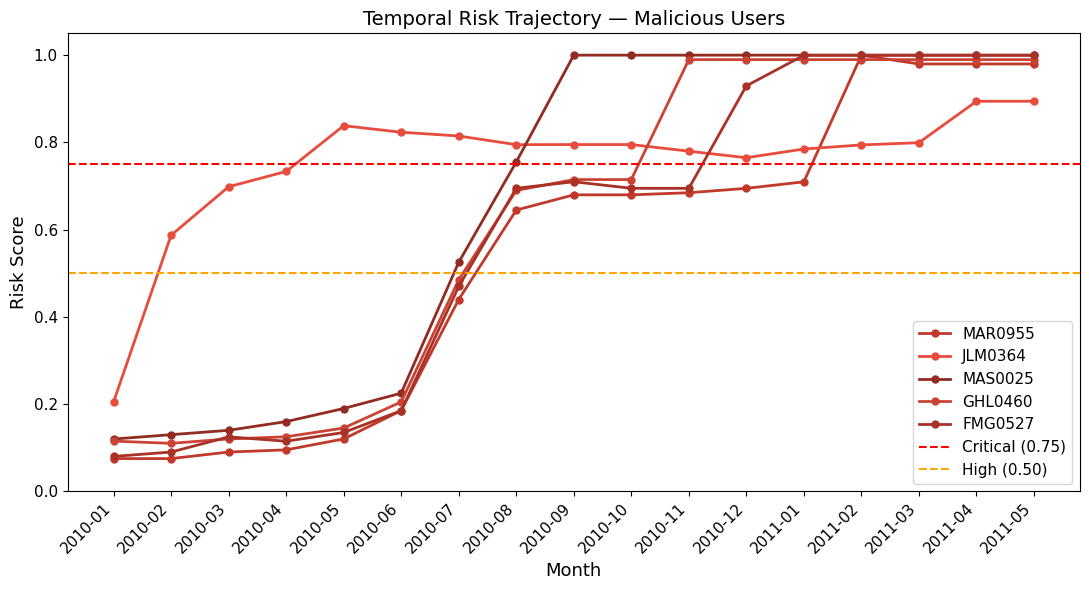

Saved: Risk_Trajectory_Malicious.png


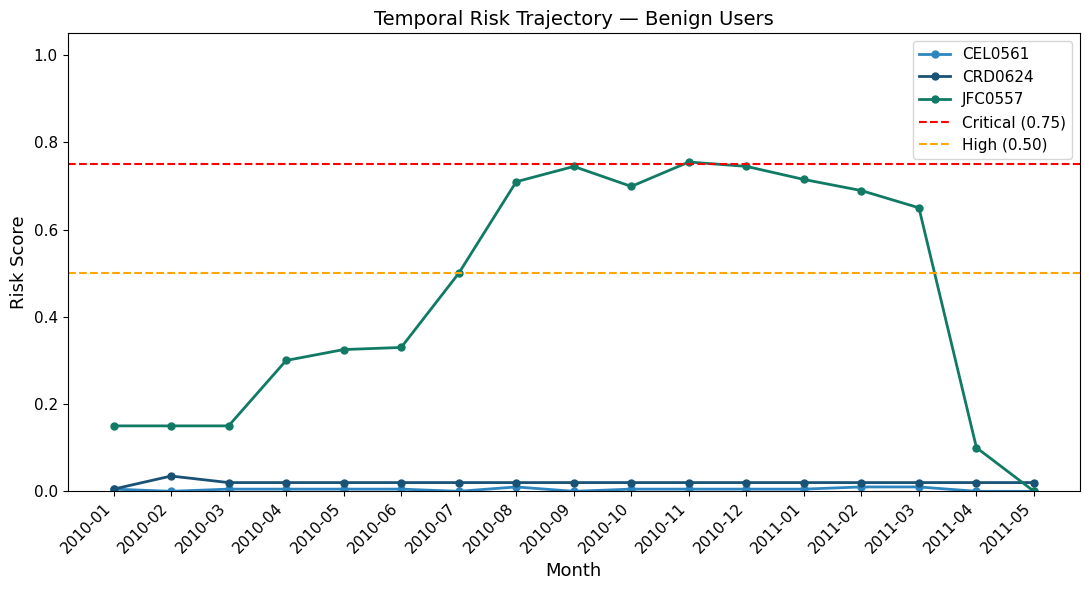

Saved: Risk_Trajectory_Benign.png


In [45]:
# ── CELL 8.6: TEMPORAL RISK TRAJECTORY ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("Cell 8.6: Temporal Risk Trajectory")
print("=" * 55)

# ── Build monthly activity features per user ──────────────────────────────────
logon['year_month'] = logon['date'].dt.to_period('M')
email['date_dt']    = pd.to_datetime(email['date'])
email['year_month'] = email['date_dt'].dt.to_period('M')

months = sorted(logon['year_month'].unique())
print(f"\nObservation months: {months[0]} to {months[-1]} ({len(months)} months)")

# Select users to track: 5 malicious + 3 benign
malicious_users = merged_v2[merged_v2['label']==1]['user'].values[:5]
benign_users    = merged_v2[merged_v2['label']==0]['user'].values[:3]
tracked_users   = list(malicious_users) + list(benign_users)
print(f"\nTracking {len(malicious_users)} malicious + "
      f"{len(benign_users)} benign users")

# ── Compute monthly risk scores ────────────────────────────────────────────────
monthly_records = []

for month in months:
    logon_m  = logon[logon['year_month'] <= month]
    email_m  = email[email['year_month'] <= month]
    device_m = device.copy()

    lf = logon_m.groupby('user').agg(
        logon_count      =('activity', lambda x: (x=='Logon').sum()),
        logoff_count     =('activity', lambda x: (x=='Logoff').sum()),
        after_hours_logon=('is_after_hours','sum'),
        unique_pcs       =('pc','nunique')
    ).reset_index()

    df_m = device_m.groupby('user').agg(
        device_count  =('activity','count'),
        unique_devices=('pc','nunique')
    ).reset_index()

    ef = email_m.groupby('user').agg(
        email_sent       =('id','count'),
        avg_email_size   =('size','mean'),
        total_attachments=('attachments','sum'),
        unique_recipients=('to','nunique')
    ).reset_index()

    active = logon_m.groupby('user')['date'].apply(
        lambda x: x.dt.date.nunique()).reset_index()
    active.columns = ['user','active_days']

    ah_r = lf.copy()
    ah_r['after_hours_ratio'] = (
        ah_r['after_hours_logon'] / ah_r['logon_count'].clip(lower=1))

    udpd = df_m.merge(active, on='user', how='left')
    udpd['unique_devices_per_day'] = (
        udpd['unique_devices'] / udpd['active_days'].clip(lower=1))

    lbr_daily = logon_m.copy()
    lbr_daily['date_only'] = lbr_daily['date'].dt.date
    daily_l = lbr_daily.groupby(['user','date_only']).size().reset_index(name='dc')
    lbr = daily_l.groupby('user').agg(
        avg_dl=('dc','mean'), peak_dl=('dc','max')).reset_index()
    lbr['logon_burst_ratio'] = lbr['peak_dl'] / lbr['avg_dl'].clip(lower=1)

    ebr_daily = email_m.copy()
    ebr_daily['date_only'] = ebr_daily['date_dt'].dt.date
    daily_e = ebr_daily.groupby(['user','date_only']).size().reset_index(name='ec')
    ebr = daily_e.groupby('user').agg(
        avg_de=('ec','mean'), peak_de=('ec','max')).reset_index()
    ebr['email_burst_ratio'] = ebr['peak_de'] / ebr['avg_de'].clip(lower=1)

    snap = psych_features.copy()
    snap = snap.merge(lf,   on='user', how='left')
    snap = snap.merge(df_m, on='user', how='left')
    snap = snap.merge(ef,   on='user', how='left')
    snap = snap.merge(ah_r[['user','after_hours_ratio']], on='user', how='left')
    snap = snap.merge(udpd[['user','unique_devices_per_day']], on='user', how='left')
    snap = snap.merge(lbr[['user','logon_burst_ratio']], on='user', how='left')
    snap = snap.merge(ebr[['user','email_burst_ratio']], on='user', how='left')
    snap[feature_cols_v2] = snap[feature_cols_v2].fillna(0)

    snap_tracked = snap[snap['user'].isin(tracked_users)]
    if len(snap_tracked) == 0:
        continue

    X_snap = scaler_v2.transform(snap_tracked[feature_cols_v2].values)
    scores = rf_v2.predict_proba(X_snap)[:, 1]

    for user, score in zip(snap_tracked['user'].values, scores):
        label = merged_v2[merged_v2['user']==user]['label'].values[0]
        monthly_records.append({
            'month': str(month), 'user': user,
            'risk_score': score, 'label': label
        })

traj_df = pd.DataFrame(monthly_records)
print(f"\nTrajectory records: {traj_df.shape}")

mal_colors = ['#C0392B','#E74C3C','#922B21','#CB4335','#A93226']
ben_colors = ['#2E86C1','#1A5276','#117A65']
month_labels = [str(m) for m in months]

# ── Plot 1: Malicious user trajectories ───────────────────────────────────────
plt.figure(figsize=(11, 6))
for i, user in enumerate(malicious_users):
    ud = traj_df[traj_df['user']==user].sort_values('month')
    plt.plot(range(len(ud)), ud['risk_score'],
             color=mal_colors[i], linewidth=2,
             marker='o', markersize=5, label=user)

plt.axhline(y=0.75, color='red', linestyle='--',
            linewidth=1.5, label='Critical (0.75)')
plt.axhline(y=0.50, color='orange', linestyle='--',
            linewidth=1.5, label='High (0.50)')
plt.xticks(range(len(months)), month_labels,
           rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Risk Score', fontsize=13)
plt.xlabel('Month', fontsize=13)
plt.title('Temporal Risk Trajectory — Malicious Users', fontsize=14)
plt.legend(fontsize=11)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("Risk_Trajectory_Malicious.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Risk_Trajectory_Malicious.png")

# ── Plot 2: Benign user trajectories ──────────────────────────────────────────
plt.figure(figsize=(11, 6))
for i, user in enumerate(benign_users):
    ud = traj_df[traj_df['user']==user].sort_values('month')
    plt.plot(range(len(ud)), ud['risk_score'],
             color=ben_colors[i], linewidth=2,
             marker='o', markersize=5, label=user)

plt.axhline(y=0.75, color='red', linestyle='--',
            linewidth=1.5, label='Critical (0.75)')
plt.axhline(y=0.50, color='orange', linestyle='--',
            linewidth=1.5, label='High (0.50)')
plt.xticks(range(len(months)), month_labels,
           rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Risk Score', fontsize=13)
plt.xlabel('Month', fontsize=13)
plt.title('Temporal Risk Trajectory — Benign Users', fontsize=14)
plt.legend(fontsize=11)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("Risk_Trajectory_Benign.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Risk_Trajectory_Benign.png")

Cell 8.7: Risk Velocity (30-day Score Change)

Velocity alert threshold: +0.1 per month
High velocity events detected: 18

High velocity events by user:
   user   month    score  velocity  label
MAR0955 2010-07 0.439723  0.254764      1
MAR0955 2010-08 0.644723  0.205000      1
MAR0955 2011-02 0.999764  0.290202      1
JLM0364 2010-02 0.586968  0.382176      1
JLM0364 2010-03 0.698258  0.111290      1
JLM0364 2010-05 0.838258  0.105000      1
MAS0025 2010-07 0.524979  0.299979      1
MAS0025 2010-08 0.754979  0.230000      1
MAS0025 2010-09 0.999979  0.245000      1
GHL0460 2010-07 0.484723  0.279764      1
GHL0460 2010-08 0.689723  0.205000      1
GHL0460 2010-11 0.989723  0.275000      1
FMG0527 2010-07 0.469723  0.284926      1
FMG0527 2010-08 0.694723  0.225000      1
FMG0527 2010-12 0.929562  0.235000      1
JFC0557 2010-04 0.299979  0.149979      0
JFC0557 2010-07 0.499765  0.169947      0
JFC0557 2010-08 0.709765  0.210000      0


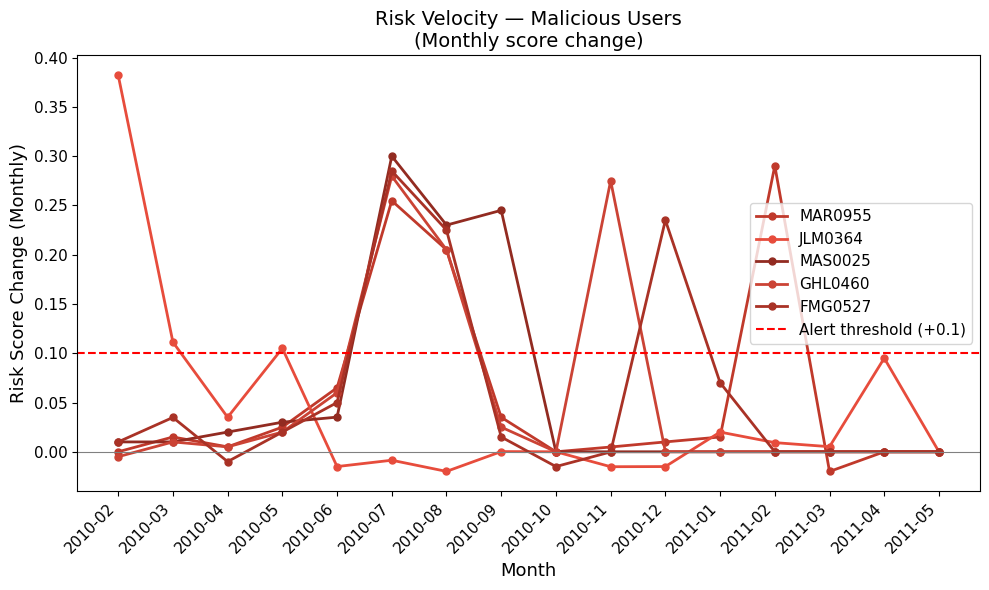

Saved: Risk_Velocity_Malicious.png


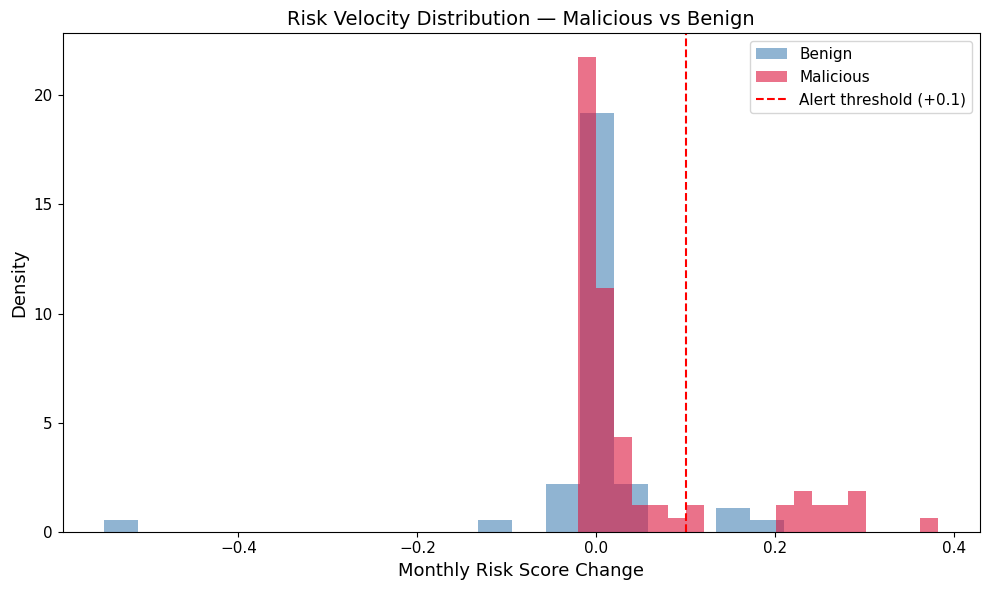

Saved: Risk_Velocity_Distribution.png


In [44]:
# ── CELL 8.7: RISK VELOCITY ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("Cell 8.7: Risk Velocity (30-day Score Change)")
print("=" * 55)

# ── Compute velocity: score_t minus score_t-1 ─────────────────────────────────
velocity_records = []

for user in tracked_users:
    ud = traj_df[traj_df['user']==user].sort_values('month').reset_index(drop=True)
    label = ud['label'].iloc[0]
    for i in range(1, len(ud)):
        velocity = ud['risk_score'].iloc[i] - ud['risk_score'].iloc[i-1]
        velocity_records.append({
            'user':     user,
            'month':    ud['month'].iloc[i],
            'score':    ud['risk_score'].iloc[i],
            'velocity': velocity,
            'label':    label
        })

vel_df = pd.DataFrame(velocity_records)

VEL_THRESHOLD = 0.10
high_vel = vel_df[vel_df['velocity'] >= VEL_THRESHOLD]
print(f"\nVelocity alert threshold: +{VEL_THRESHOLD} per month")
print(f"High velocity events detected: {len(high_vel)}")
print(f"\nHigh velocity events by user:")
print(high_vel[['user','month','score','velocity','label']].to_string(index=False))

# ── Plot 1: Velocity over time — Malicious Users ──────────────────────────────
plt.figure(figsize=(10, 6))
for i, user in enumerate(malicious_users):
    ud = vel_df[vel_df['user']==user]
    plt.plot(range(len(ud)), ud['velocity'],
             color=mal_colors[i], linewidth=2,
             marker='o', markersize=5, label=user)

plt.axhline(y=VEL_THRESHOLD, color='red', linestyle='--',
            linewidth=1.5, label=f'Alert threshold (+{VEL_THRESHOLD})')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
plt.xticks(range(len(months)-1),
           [str(m) for m in months[1:]],
           rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Risk Score Change (Monthly)', fontsize=13)
plt.xlabel('Month', fontsize=13)
plt.title('Risk Velocity — Malicious Users\n(Monthly score change)',
          fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("Risk_Velocity_Malicious.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Risk_Velocity_Malicious.png")

# ── Plot 2: Velocity Distribution — Malicious vs Benign ───────────────────────
plt.figure(figsize=(10, 6))
mal_vel = vel_df[vel_df['label']==1]['velocity']
ben_vel = vel_df[vel_df['label']==0]['velocity']

plt.hist(ben_vel, bins=20, alpha=0.6, color='steelblue',
         label='Benign', density=True)
plt.hist(mal_vel, bins=20, alpha=0.6, color='crimson',
         label='Malicious', density=True)
plt.axvline(x=VEL_THRESHOLD, color='red', linestyle='--',
            linewidth=1.5, label=f'Alert threshold (+{VEL_THRESHOLD})')
plt.xlabel('Monthly Risk Score Change', fontsize=13)
plt.ylabel('Density', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Risk Velocity Distribution — Malicious vs Benign', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("Risk_Velocity_Distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Risk_Velocity_Distribution.png")

Cell 8.8: Feature Stability and Policy-to-Feature Mapping

Computing SHAP ranks across 5 folds (may take ~60 seconds)...
  Fold 1 done
  Fold 2 done
  Fold 3 done
  Fold 4 done
  Fold 5 done

Feature Stability (lower std = more stable rank):
Feature                        Mean Rank    Std Dev      Stability
-----------------------------------------------------------------
unique_devices_per_day         1.00         0.00         HIGH
device_count                   2.00         0.00         HIGH
logoff_count                   3.00         0.00         HIGH
unique_devices                 4.00         0.00         HIGH
email_burst_ratio              5.00         0.00         HIGH
logon_count                    6.00         0.00         HIGH
after_hours_logon              7.40         0.55         HIGH
total_attachments              8.00         1.00         HIGH
email_sent                     8.60         0.55         HIGH
logon_burst_ratio              10.60        0.89         HIGH
after

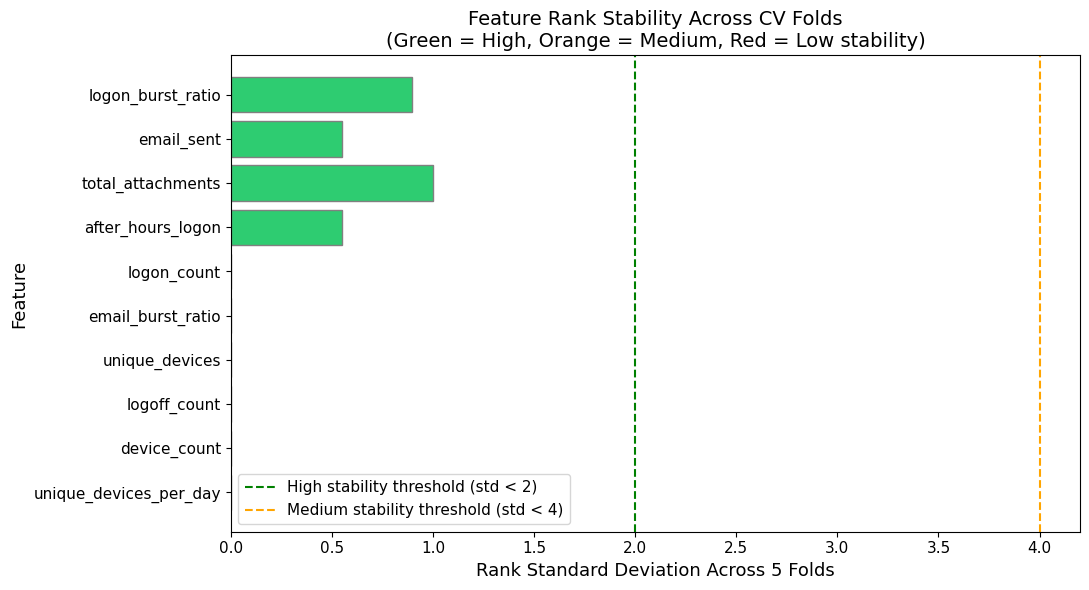


Saved: Feature_Stability.png


In [47]:
# ── CELL 8.8: FEATURE STABILITY AND POLICY-TO-FEATURE MAPPING ────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 55)
print("Cell 8.8: Feature Stability and Policy-to-Feature Mapping")
print("=" * 55)

# ── Feature stability: SHAP rank consistency across CV folds ──────────────────
from sklearn.model_selection import StratifiedKFold
import shap

cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_ranks = []

print("\nComputing SHAP ranks across 5 folds (may take ~60 seconds)...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_all_scaled, y_all), 1):
    X_tr, X_te = X_all_scaled[train_idx], X_all_scaled[test_idx]
    y_tr       = y_all[train_idx]

    from sklearn.ensemble import RandomForestClassifier
    from imblearn.over_sampling import SMOTE
    smote_f         = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = smote_f.fit_resample(X_tr, y_tr)

    rf_fold = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1)
    rf_fold.fit(X_tr_sm, y_tr_sm)

    exp_fold   = shap.TreeExplainer(rf_fold)
    sv_fold    = exp_fold.shap_values(X_te)
    sv_mal     = sv_fold[:, :, 1]
    mean_shap  = np.abs(sv_mal).mean(axis=0)
    ranks      = pd.Series(mean_shap, index=feature_cols_v2).rank(
        ascending=False)
    fold_ranks.append(ranks)
    print(f"  Fold {fold} done")

rank_df   = pd.DataFrame(fold_ranks)
mean_rank = rank_df.mean()
std_rank  = rank_df.std()

stability_df = pd.DataFrame({
    'feature':   feature_cols_v2,
    'mean_rank': mean_rank.values,
    'std_rank':  std_rank.values
}).sort_values('mean_rank')

print(f"\nFeature Stability (lower std = more stable rank):")
print(f"{'Feature':<30} {'Mean Rank':<12} {'Std Dev':<12} {'Stability'}")
print("-" * 65)
for _, row in stability_df.iterrows():
    stability = "HIGH" if row['std_rank'] < 2 else (
                "MEDIUM" if row['std_rank'] < 4 else "LOW")
    print(f"{row['feature']:<30} {row['mean_rank']:<12.2f} "
          f"{row['std_rank']:<12.2f} {stability}")

# ── Policy-to-feature mapping ─────────────────────────────────────────────────
print("\n" + "=" * 55)
print("Policy-to-Feature Mapping (CMMC Alignment)")
print("=" * 55)

policy_map = {
    'BYOD Policy Change':
        ['unique_devices', 'unique_devices_per_day', 'device_count'],
    'Remote Work / WFH Policy':
        ['after_hours_logon', 'after_hours_ratio', 'unique_pcs'],
    'Email DLP Policy':
        ['email_sent', 'total_attachments', 'unique_recipients',
         'avg_email_size', 'email_burst_ratio'],
    'Shared Workstation Policy':
        ['unique_pcs', 'logon_count', 'logoff_count', 'logon_burst_ratio'],
    'USB/Removable Media Policy':
        ['unique_devices', 'device_count', 'unique_devices_per_day'],
    'Flex Hours / Shift Work Policy':
        ['after_hours_logon', 'after_hours_ratio']
}

print(f"\n{'Policy Change':<30} {'Affected Features':<45} {'Retraining Required'}")
print("-" * 85)
for policy, features in policy_map.items():
    shap_impact = sum(
        stability_df[stability_df['feature']==f]['mean_rank'].values[0]
        if f in stability_df['feature'].values else 99
        for f in features
    )
    retrain = "YES — High Impact" if shap_impact < 30 else "MONITOR"
    print(f"{policy:<30} {', '.join(features[:2]) + '...':<45} {retrain}")

# ── Plot: Feature stability ────────────────────────────────────────────────────
top_stable = stability_df.head(10)

plt.figure(figsize=(11, 6))
colors = ['#2ECC71' if s < 2 else '#F39C12' if s < 4 else '#E74C3C'
          for s in top_stable['std_rank']]
bars = plt.barh(top_stable['feature'], top_stable['std_rank'],
                color=colors, edgecolor='gray')
plt.axvline(x=2, color='green', linestyle='--',
            linewidth=1.5, label='High stability threshold (std < 2)')
plt.axvline(x=4, color='orange', linestyle='--',
            linewidth=1.5, label='Medium stability threshold (std < 4)')
plt.xlabel('Rank Standard Deviation Across 5 Folds', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.title('Feature Rank Stability Across CV Folds\n'
          '(Green = High, Orange = Medium, Red = Low stability)',
          fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("Feature_Stability.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: Feature_Stability.png")